<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask:
      linear-gradient(#fff 0 0) content-box,
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>01 $\rightarrow$ Emotion AI — Key Facial Points Detection</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">Deep Learning with Convolutional Neural Networks &amp; Residual Blocks</span>
</div>


---

# Table of Contents

1. [Project Overview and Business Case](#1-project-overview)
   - 1.1 [Key Facial Points Detection](#11-overview)
   - 1.2 [Inputs and Outputs](#12-inputs-outputs)
2. [Import Libraries/Datasets and Data Processing](#2-import-data)
3. [Perform Image Visualization](#3-image-visualization)
4. [Perform Image Augmentation](#4-image-augmentation)
5. [Normalization and Training Data Preparation](#5-normalization)
6. [Deep Neural Networks — Theory and Intuition](#6-deep-learning-theory)
   - 6.1 [Deep Learning History](#61-dl-history)
   - 6.2 [Convolutional Neural Networks](#62-cnn)
   - 6.3 [ResNet (Residual Network)](#63-resnet)
7. [Build Deep Residual Neural Network Model](#7-build-model)
   - 7.1 [Model Architecture](#71-model-architecture)
   - 7.2 [Convolution Block vs. Identity Block](#72-conv-identity-blocks)
8. [Compile and Train Deep Learning Model](#8-train-model)
9. [Assess Trained Model Performance](#9-assess-performance)
10. [Mini Challenge Solutions](#mini-challenge-solutions)

---


<a id="1-project-overview"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">01. Project Overview and Business Case</span>


<a id="11-overview"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">1.1 Key Facial Points Detection</span>

- In this project, we will create a deep learning model based on Convolutional Neural Network and Residual Blocks to predict facial key-points.
- Facial Key-Point Detection serves as a basis for Emotional AI applications like detecting customer emotional responses to Ads and Driver Monitoring Systems.
- **AFFECTIVA** is one of the leading players in Emotional AI and their software detects human emotions, complex cognitive states, and behaviours.
- Check this out: https://go.affectiva.com/auto
- Data Source: https://www.kaggle.com/c/facial-keypoints-detection/data


![Facial Keypoints Examples](assets/task1_project_overview.png)


<a id="12-inputs-outputs"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">1.2 Inputs and Outputs</span>

- The dataset consists of x and y coordinates of 15 facial key points.
- Input Images are 96 x 96 pixels.
- Images consist of only one color channel (gray-scale images).
- The model takes a 96x96 grayscale input image, passes it through a trained Key Facial Points Detector Model, and outputs the (x, y) coordinates for all 15 key facial points.


![Model Pipeline](assets/task1_facial_keypoints_data.png)


<a id="2-import-data"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">02. Import Libraries/Datasets and Perform Preliminary Data Processing</span>


In [1]:
# ============================================
# Import Required Libraries
# ============================================

# Data handling
import pandas as pd
import numpy as np
import copy
import random

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt

# Deep Learning — TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, Dense, Conv2D, MaxPooling2D, AveragePooling2D,
    ZeroPadding2D, Flatten, Dropout, Add, Activation, BatchNormalization
)
from tensorflow.keras.initializers import GlorotUniform
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
)
from tensorflow.keras.utils import plot_model

# Display settings
from IPython.display import display

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


TensorFlow version: 2.20.0
NumPy version: 2.1.3
Pandas version: 2.2.3


In [2]:
# ============================================
# Load the Facial Keypoints Dataset
# ============================================
import os

# Automatically detect dataset location (Local workspace, current dir, or Google Colab)
csv_candidates = [
    'data/KeyFacialPoints.csv',
    'KeyFacialPoints.csv',
    '/content/KeyFacialPoints.csv',
    '/content/data/KeyFacialPoints.csv'
]

csv_path = next((path for path in csv_candidates if os.path.exists(path)), 'data/KeyFacialPoints.csv')
facialpoints_df = pd.read_csv(csv_path)

print(f"Dataset successfully loaded from: {csv_path}")
print(f"Dataset shape: {facialpoints_df.shape}")
print(f"Number of images: {facialpoints_df.shape[0]}")
print(f"Number of columns: {facialpoints_df.shape[1]}")

Dataset successfully loaded from: KeyFacialPoints.csv
Dataset shape: (407, 31)
Number of images: 407
Number of columns: 31


In [3]:
# Preview the first 5 rows of the dataset
facialpoints_df.head(5)

,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y,Image
0,66.033564,39.002274,30.227008,36.421678,59.582075,39.647423,73.130346,39.969997,36.356571,37.389402,...,57.066803,61.195308,79.970165,28.614496,77.388992,43.312602,72.935459,43.130707,84.485774,238 236 237 238 240 240 239 241 241 243 240 23...
1,64.332936,34.970077,29.949277,33.448715,58.856170,35.274349,70.722723,36.187166,36.034723,34.361532,...,55.660936,56.421447,76.352000,35.122383,76.047660,46.684596,70.266553,45.467915,85.480170,219 215 204 196 204 211 212 200 180 168 178 19...
2,65.057053,34.909642,30.903789,34.909642,59.412000,36.320968,70.984421,36.320968,37.678105,36.320968,...,53.538947,60.822947,73.014316,33.726316,72.732000,47.274947,70.191789,47.274947,78.659368,144 142 159 180 188 188 184 180 167 132 84 59 ...
3,65.225739,37.261774,32.023096,37.261774,60.003339,39.127179,72.314713,38.380967,37.618643,38.754115,...,54.166539,65.598887,72.703722,37.245496,74.195478,50.303165,70.091687,51.561183,78.268383,193 192 193 194 194 194 193 192 168 111 50 12 ...
4,66.725301,39.621261,32.244810,38.042032,58.565890,39.621261,72.515926,39.884466,36.982380,39.094852,...,64.889521,60.671411,77.523239,31.191755,76.997301,44.962748,73.707387,44.227141,86.871166,147 148 160 196 215 214 216 217 219 220 206 18...


In [4]:
# Check data types and non-null counts for each column
facialpoints_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   left_eye_center_x          407 non-null    float64
 1   left_eye_center_y          407 non-null    float64
 2   right_eye_center_x         407 non-null    float64
 3   right_eye_center_y         407 non-null    float64
 4   left_eye_inner_corner_x    407 non-null    float64
 5   left_eye_inner_corner_y    407 non-null    float64
 6   left_eye_outer_corner_x    407 non-null    float64
 7   left_eye_outer_corner_y    407 non-null    float64
 8   right_eye_inner_corner_x   407 non-null    float64
 9   right_eye_inner_corner_y   407 non-null    float64
 10  right_eye_outer_corner_x   407 non-null    float64
 11  right_eye_outer_corner_y   407 non-null    float64
 12  left_eyebrow_inner_end_x   407 non-null    float64
 13  left_eyebrow_inner_end_y   407 non-null    float64

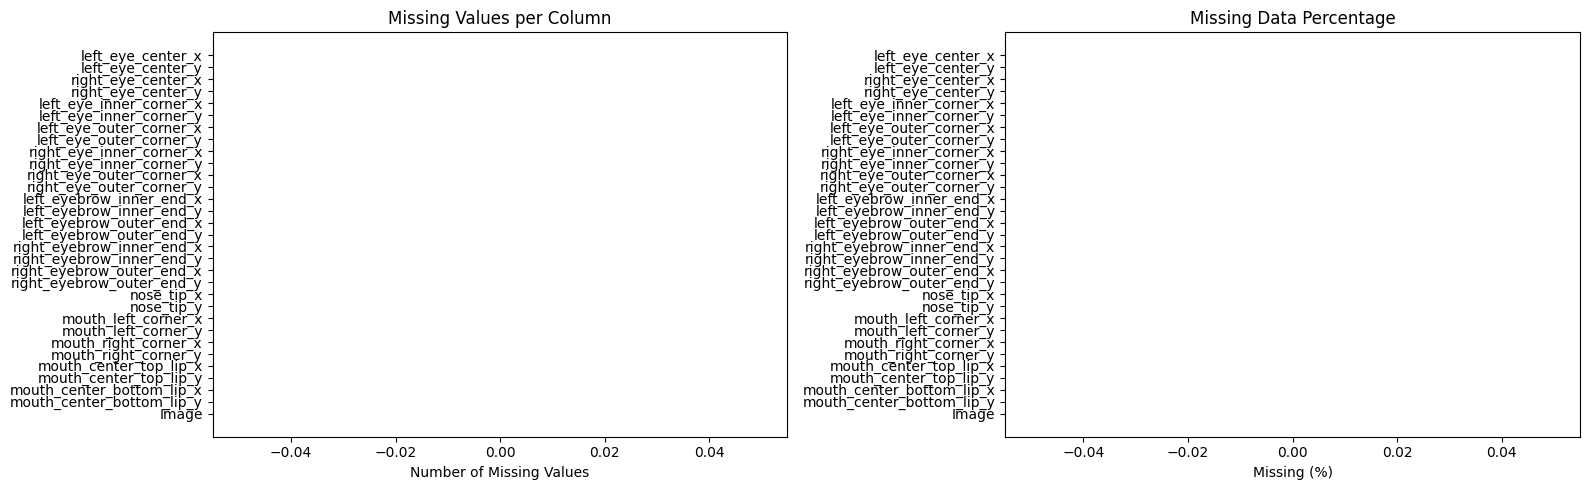

Total missing values: 0


In [5]:
# Visualize missing values across all columns
missing_counts = facialpoints_df.isnull().sum()
missing_pct = (missing_counts / len(facialpoints_df)) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart of missing counts
axes[0].barh(missing_counts.index, missing_counts.values, color='coral')
axes[0].set_xlabel('Number of Missing Values')
axes[0].set_title('Missing Values per Column')
axes[0].invert_yaxis()

# Percentage chart
colors = ['green' if pct == 0 else 'red' for pct in missing_pct.values]
axes[1].barh(missing_pct.index, missing_pct.values, color=colors)
axes[1].set_xlabel('Missing (%)')
axes[1].set_title('Missing Data Percentage')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Total missing values: {missing_counts.sum()}")

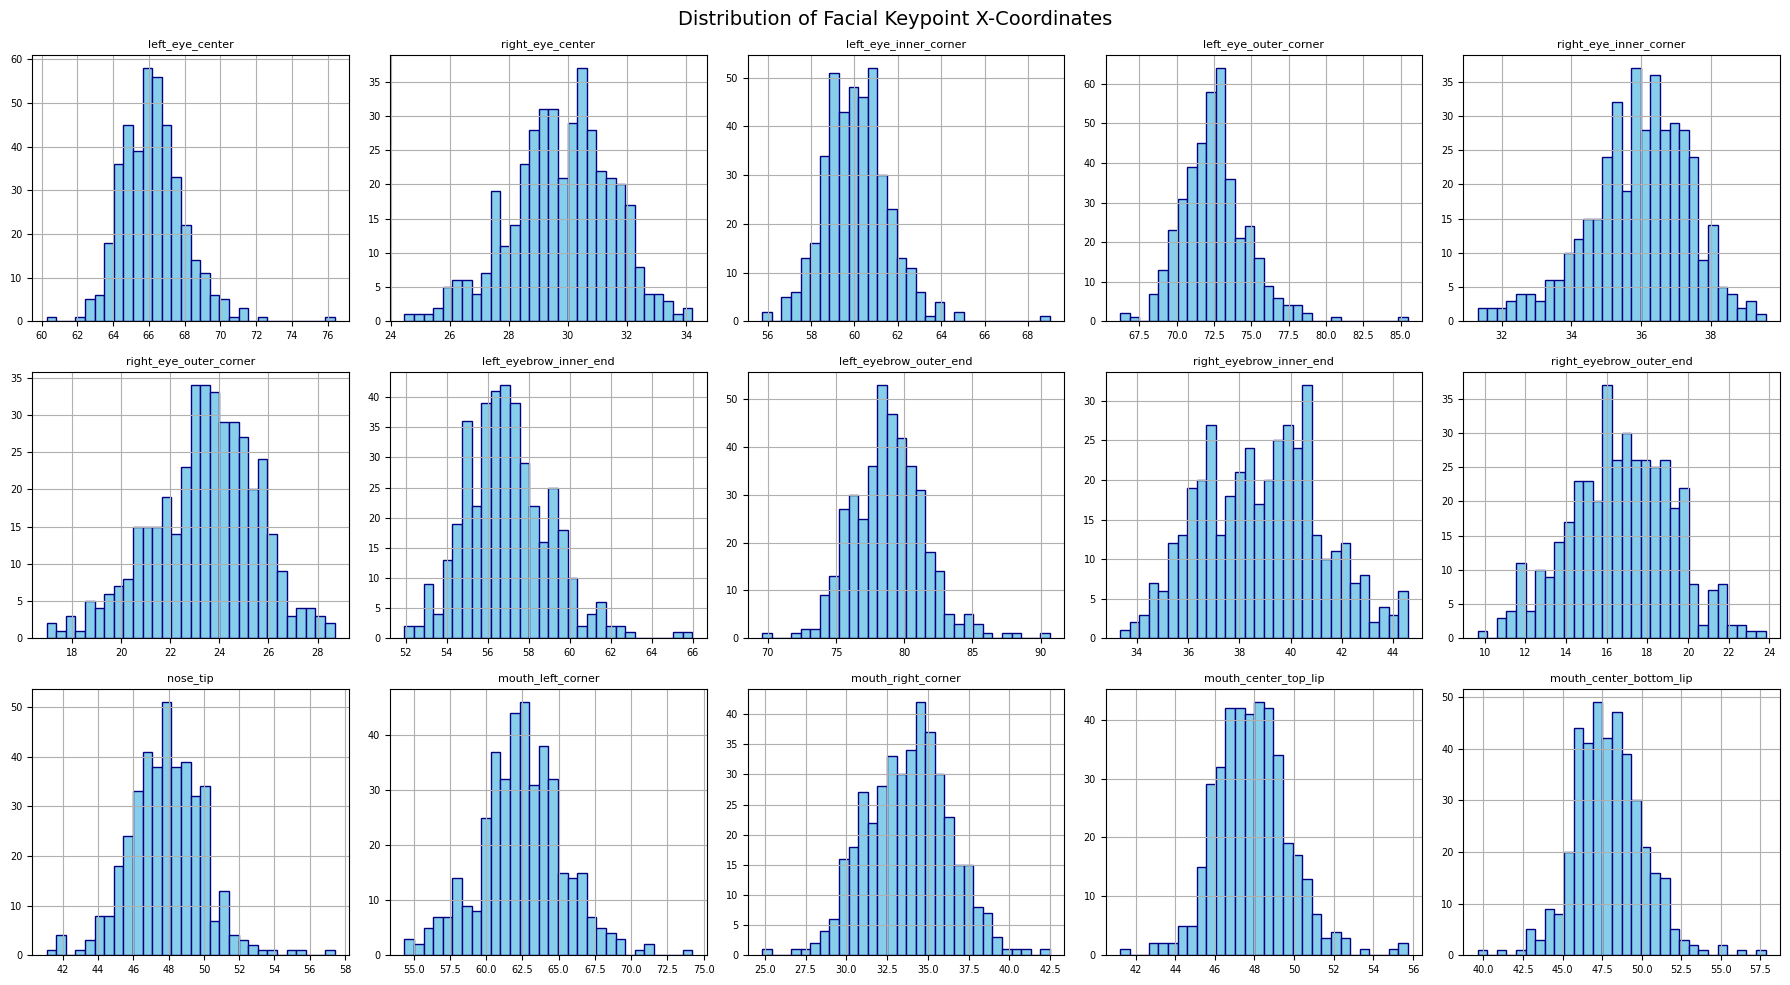

In [6]:
# Distribution of keypoint coordinate values
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.suptitle('Distribution of Facial Keypoint X-Coordinates', fontsize=14)

keypoint_names = [col for col in facialpoints_df.columns if col.endswith('_x')]

for idx, col in enumerate(keypoint_names):
    row = idx // 5
    col_idx = idx % 5
    ax = axes[row, col_idx]
    facialpoints_df[col].dropna().hist(ax=ax, bins=30, color='skyblue', edgecolor='navy')
    ax.set_title(col.replace('_x', ''), fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

In [7]:
# Look at a sample image — pixel values are stored as a space-separated string
print(f"Type of Image column: {type(facialpoints_df['Image'][0])}")
print(f"First 100 characters: {facialpoints_df['Image'][0][:100]}...")

Type of Image column: <class 'str'>
First 100 characters: 238 236 237 238 240 240 239 241 241 243 240 239 231 212 190 173 148 122 104 92 79 73 74 73 73 74 81 ...


In [8]:
# ====================================================================
# Convert Space-Separated Pixel Strings into 96x96 NumPy Arrays
# ====================================================================

def parse_image_pixels(pixel_data):
    """
    Converts space-separated pixel string to a (96, 96) numpy array.
    Safely handles already-parsed arrays and detects truncated rows.
    """
    if isinstance(pixel_data, np.ndarray):
        return pixel_data.reshape(96, 96) if pixel_data.size == 9216 else None
    if isinstance(pixel_data, str):
        arr = np.fromstring(pixel_data, dtype=int, sep=' ')
        if arr.shape[0] == 9216:
            return arr.reshape(96, 96)
    return None

# Parse each image safely
facialpoints_df['Image'] = facialpoints_df['Image'].apply(parse_image_pixels)

# Check and drop any corrupted or truncated rows (e.g., from an interrupted upload)
corrupted_count = facialpoints_df['Image'].isnull().sum()
if corrupted_count > 0:
    print(f"Note: Filtered out {corrupted_count} truncated/corrupted image row(s).")
    facialpoints_df = facialpoints_df.dropna(subset=['Image']).reset_index(drop=True)

print(f"Parsed image shape: {facialpoints_df['Image'][0].shape}")
print(f"Total valid images: {len(facialpoints_df)}")
print(f"Pixel value range: [{facialpoints_df['Image'][0].min()}, {facialpoints_df['Image'][0].max()}]")

Note: Filtered out 1 truncated/corrupted image row(s).
Parsed image shape: (96, 96)
Total valid images: 406
Pixel value range: [2, 253]


In [9]:
# Confirm the resized image dimensions
print(f"Parsed image shape: {facialpoints_df['Image'][0].shape}")
print(f"Total images parsed: {len(facialpoints_df)}")

Parsed image shape: (96, 96)
Total images parsed: 406


In [10]:
# Fill any missing keypoint values with the column mean
# numeric_only=True ensures compatibility with all Pandas versions (including Pandas 2.0+)
facialpoints_df.fillna(facialpoints_df.mean(numeric_only=True), inplace=True)

# Confirm no null values remain in the dataset
remaining_nulls = facialpoints_df.isnull().sum().sum()
print(f"Remaining null values across all columns: {remaining_nulls}")

Remaining null values across all columns: 0


<a id="mini-challenge-1"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #D97706, #B45309); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">🏆 Mini Challenge #1</span>

- Obtain the average, minimum and maximum values for 'right_eye_center_x'


# ====================================================================
# Mini Challenge #1: Obtain average, minimum, and maximum values
# for 'right_eye_center_x'
# ====================================================================

col_name = 'right_eye_center_x'

avg_val = facialpoints_df[col_name].mean()
min_val = facialpoints_df[col_name].min()
max_val = facialpoints_df[col_name].max()

print("Statistics for 'right_eye_center_x':")
print(f"  Average (Mean) : {avg_val:.2f} pixels")
print(f"  Minimum        : {min_val:.2f} pixels")
print(f"  Maximum        : {max_val:.2f} pixels")

# Display full summary statistics for 'right_eye_center_x'
facialpoints_df[[col_name]].describe()

/tmp/ipykernel_2863/2531627892.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(facialpoints_df.loc[i][j-1], facialpoints_df.loc[i][j], 'ro', markersize=4)


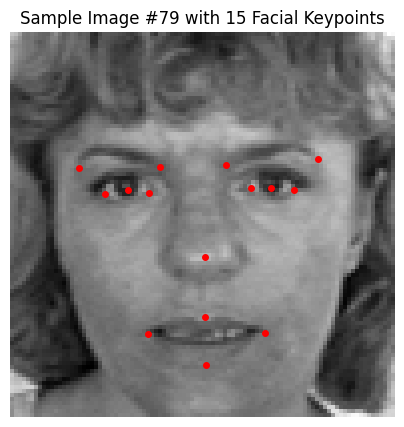

In [11]:
# Plot a random image from the dataset along with its facial keypoints
i = np.random.randint(0, len(facialpoints_df))

plt.figure(figsize=(5, 5))
plt.imshow(facialpoints_df['Image'][i], cmap='gray')
for j in range(1, 31, 2):
    plt.plot(facialpoints_df.loc[i][j-1], facialpoints_df.loc[i][j], 'ro', markersize=4)
plt.title(f'Sample Image #{i} with 15 Facial Keypoints', fontsize=12)
plt.axis('off')
plt.show()


/tmp/ipykernel_2863/205505810.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(facialpoints_df.loc[i][j-1], facialpoints_df.loc[i][j], 'ro', markersize=5)
/tmp/ipykernel_2863/205505810.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x_val = facialpoints_df.loc[i][idx]
/tmp/ipykernel_2863/205505810.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_val = facialpoints_df.loc[i][idx + 1]


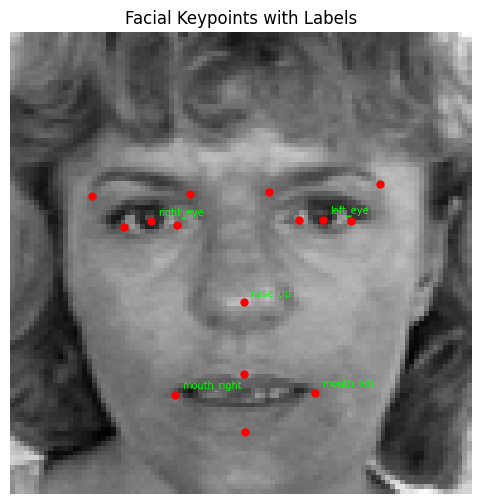

In [12]:
# Plot the (x, y) coordinates for the 15 key features on top of the image
# x-coordinates are in even columns (0, 2, 4, ...)
# y-coordinates are in odd columns (1, 3, 5, ...)

plt.figure(figsize=(6, 6))
plt.imshow(facialpoints_df['Image'][i], cmap='gray')
for j in range(1, 31, 2):
    plt.plot(facialpoints_df.loc[i][j-1], facialpoints_df.loc[i][j], 'ro', markersize=5)

# Label a few key points for clarity
keypoint_labels = ['left_eye', 'right_eye', 'nose_tip', 'mouth_left', 'mouth_right']
label_indices = [0, 2, 20, 22, 24]  # Column pairs for these landmarks
for idx, label in zip(label_indices, keypoint_labels):
    x_val = facialpoints_df.loc[i][idx]
    y_val = facialpoints_df.loc[i][idx + 1]
    plt.annotate(label, (x_val, y_val), fontsize=7, color='lime',
                 xytext=(5, 5), textcoords='offset points')

plt.title('Facial Keypoints with Labels', fontsize=12)
plt.axis('off')
plt.show()


/tmp/ipykernel_2863/3615437054.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(facialpoints_df.loc[img_idx][j-1], facialpoints_df.loc[img_idx][j], 'ro', markersize=3)


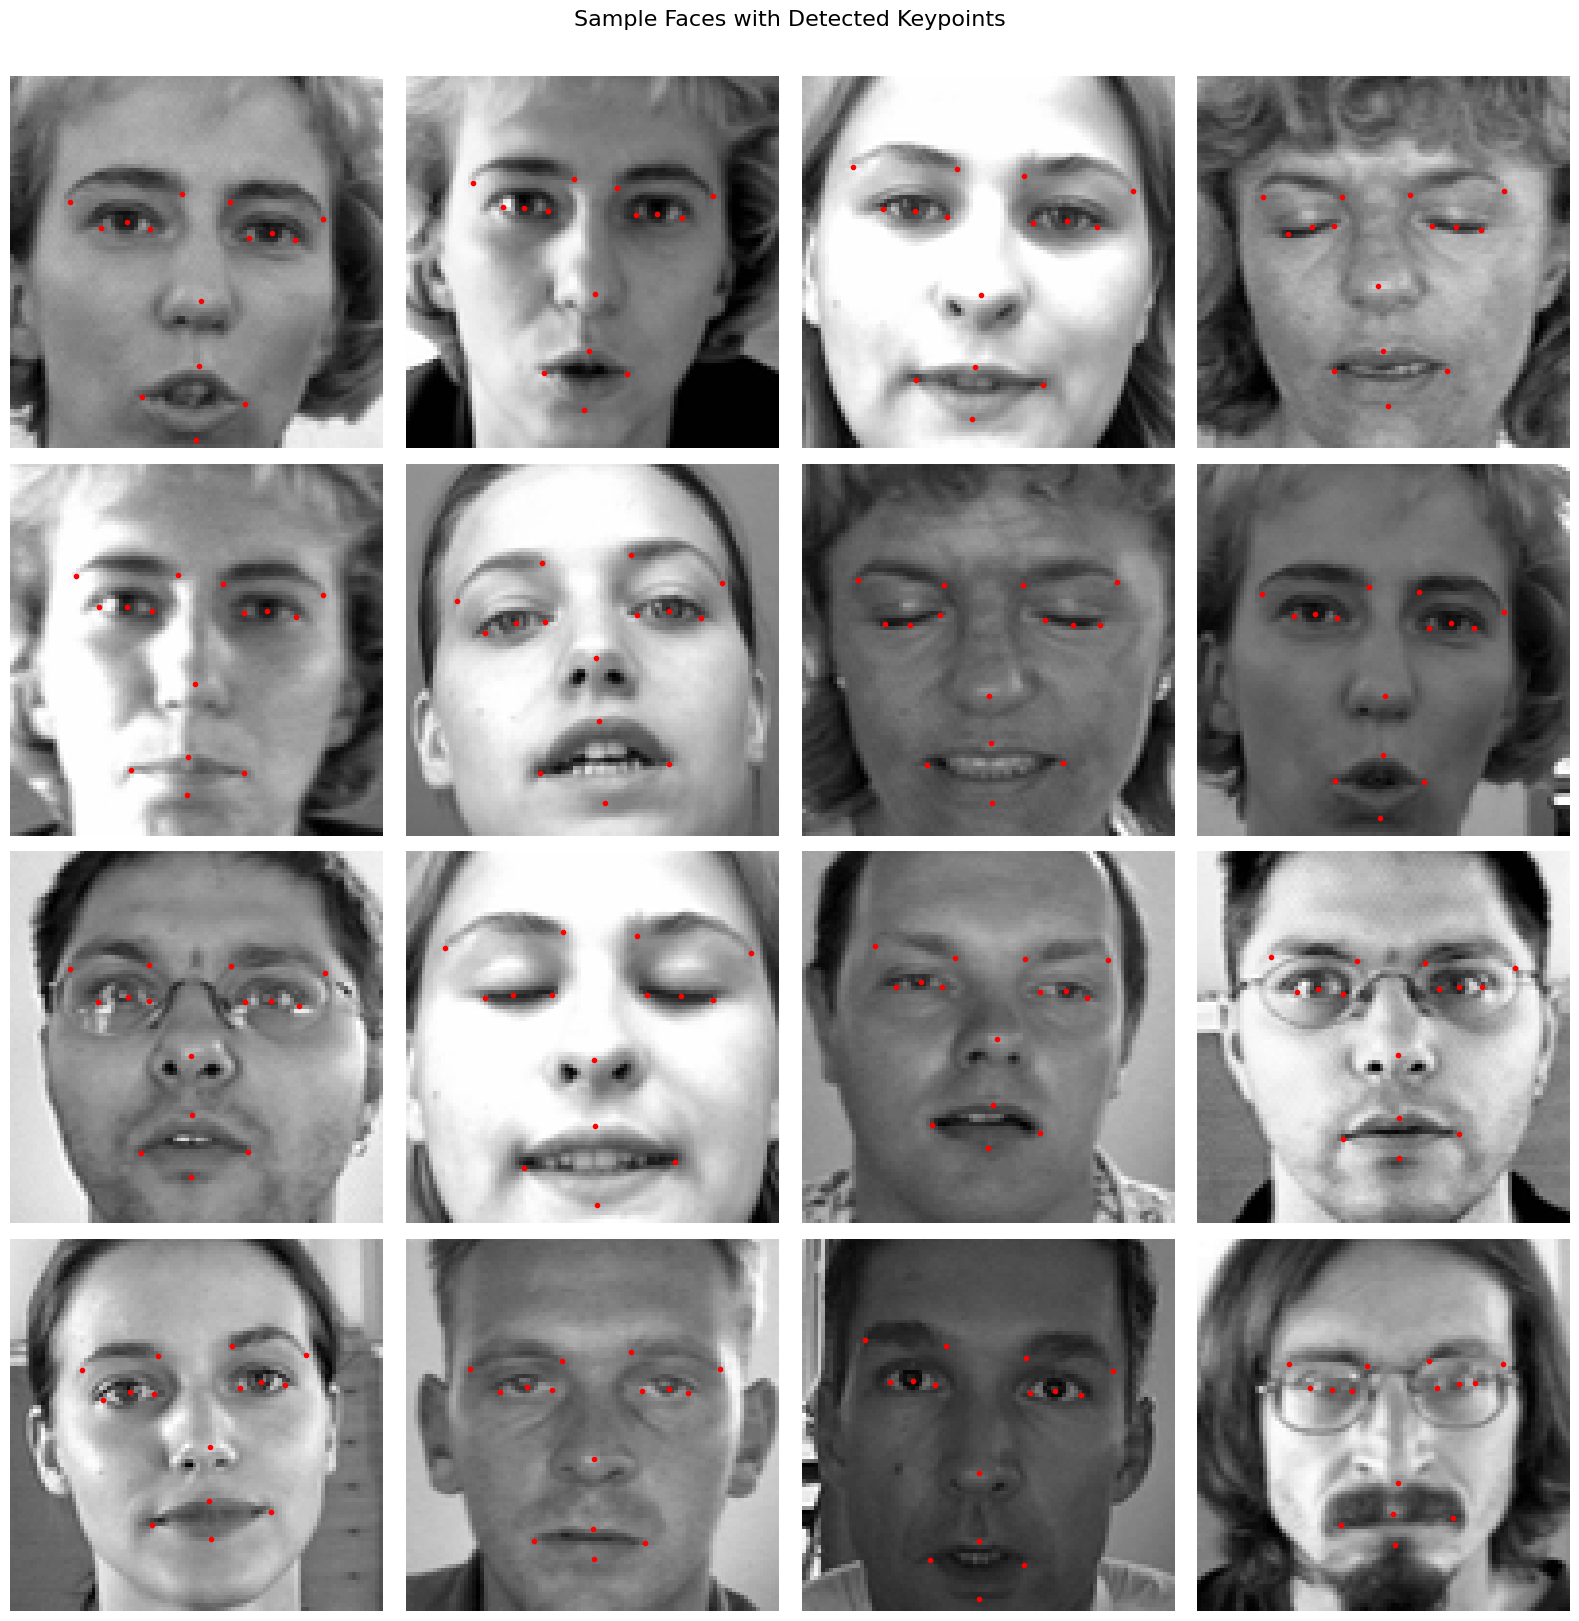

In [13]:
# View 16 sample images in a grid format with their facial keypoints

fig = plt.figure(figsize=(16, 16))
fig.suptitle('Sample Faces with Detected Keypoints', fontsize=16, y=1.01)

for i in range(16):
    ax = fig.add_subplot(4, 4, i + 1)
    img_idx = np.random.randint(0, len(facialpoints_df))
    plt.imshow(facialpoints_df['Image'][img_idx], cmap='gray')
    for j in range(1, 31, 2):
        plt.plot(facialpoints_df.loc[img_idx][j-1], facialpoints_df.loc[img_idx][j], 'ro', markersize=3)
    plt.axis('off')

plt.tight_layout()
plt.show()


<a id="mini-challenge-2"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #D97706, #B45309); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">🏆 Mini Challenge #2</span>

- Plot 64 random images from the training data instead of the 16
- HINT: You might need to choose 'random' to select random images


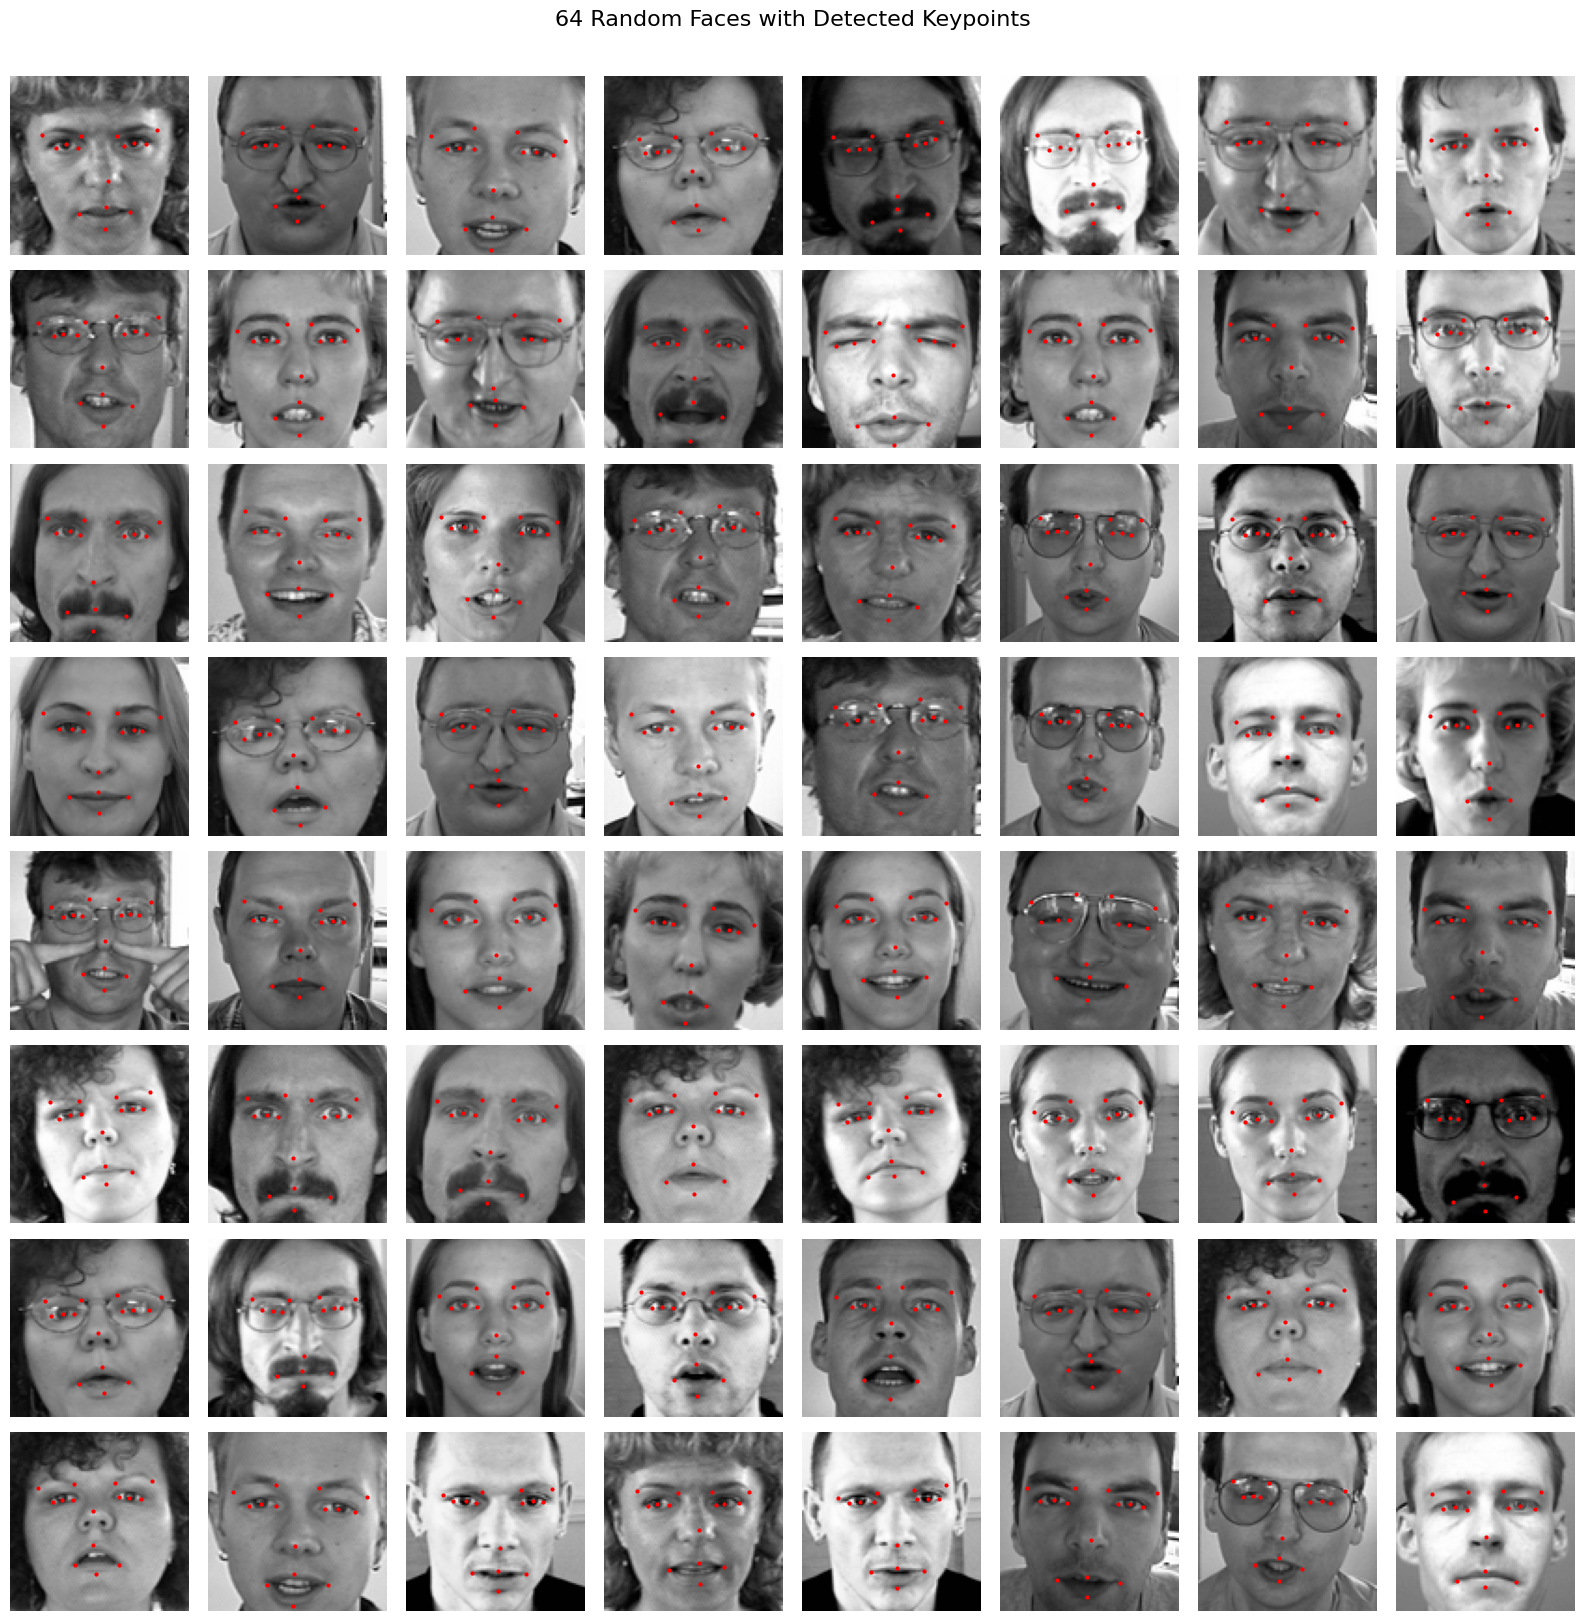

In [14]:
# ====================================================================
# Mini Challenge #2: Plot 64 random images from the dataset with keypoints
# ====================================================================

fig = plt.figure(figsize=(16, 16))
fig.suptitle('64 Random Faces with Detected Keypoints', fontsize=16, y=1.01)

for i in range(64):
    img_idx = np.random.randint(0, len(facialpoints_df))
    ax = fig.add_subplot(8, 8, i + 1)
    plt.imshow(facialpoints_df['Image'].iloc[img_idx], cmap='gray')
    for j in range(1, 31, 2):
        plt.plot(
            facialpoints_df.iloc[img_idx, j - 1],
            facialpoints_df.iloc[img_idx, j],
            'ro',
            markersize=2
        )
    plt.axis('off')

plt.tight_layout()
plt.show()

<a id="4-image-augmentation"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">04. Perform Image Augmentation</span>


In [15]:
# Create a copy of the dataframe for augmentation
facialpoints_df_copy = copy.copy(facialpoints_df)
print(f"Original dataframe shape: {facialpoints_df.shape}")


Original dataframe shape: (406, 31)


In [16]:
# Get the column names for keypoint coordinates (all 30 columns except 'Image')
columns = [col for col in facialpoints_df.columns if col != 'Image']
print(f"Number of keypoint coordinate columns: {len(columns)}")
print(f"Columns: {list(columns)}")

Number of keypoint coordinate columns: 30
Columns: ['left_eye_center_x', 'left_eye_center_y', 'right_eye_center_x', 'right_eye_center_y', 'left_eye_inner_corner_x', 'left_eye_inner_corner_y', 'left_eye_outer_corner_x', 'left_eye_outer_corner_y', 'right_eye_inner_corner_x', 'right_eye_inner_corner_y', 'right_eye_outer_corner_x', 'right_eye_outer_corner_y', 'left_eyebrow_inner_end_x', 'left_eyebrow_inner_end_y', 'left_eyebrow_outer_end_x', 'left_eyebrow_outer_end_y', 'right_eyebrow_inner_end_x', 'right_eyebrow_inner_end_y', 'right_eyebrow_outer_end_x', 'right_eyebrow_outer_end_y', 'nose_tip_x', 'nose_tip_y', 'mouth_left_corner_x', 'mouth_left_corner_y', 'mouth_right_corner_x', 'mouth_right_corner_y', 'mouth_center_top_lip_x', 'mouth_center_top_lip_y', 'mouth_center_bottom_lip_x', 'mouth_center_bottom_lip_y']


In [17]:
# Look at the pixel values of a sample image as a numpy array
print(f"Image dtype: {facialpoints_df['Image'][0].dtype}")
print(f"Image shape: {facialpoints_df['Image'][0].shape}")
facialpoints_df['Image'][0]


Image dtype: int64
Image shape: (96, 96)


array([[238, 236, 237, ..., 250, 250, 250],
       [235, 238, 236, ..., 249, 250, 251],
       [237, 236, 237, ..., 251, 251, 250],
       ...,
       [186, 183, 181, ...,  52,  57,  60],
       [189, 188, 207, ...,  61,  69,  78],
       [191, 184, 184, ...,  70,  75,  90]])

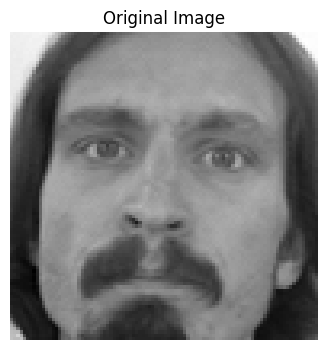

In [18]:
# Plot the original sample image (before any augmentation)
plt.figure(figsize=(4, 4))
plt.imshow(facialpoints_df['Image'][0], cmap='gray')
plt.title('Original Image', fontsize=12)
plt.axis('off')
plt.show()

In [19]:
# Flip images horizontally (along vertical axis) for data augmentation
facialpoints_df_copy['Image'] = facialpoints_df_copy['Image'].apply(
    lambda x: np.flip(x, axis=1))

print("Images flipped horizontally!")

Images flipped horizontally!


In [20]:
# Sanity check — verify that the pixel values are now flipped
print(f"Flipped image shape: {facialpoints_df_copy['Image'][0].shape}")
facialpoints_df_copy['Image'][0]


Flipped image shape: (96, 96)


array([[250, 250, 250, ..., 237, 236, 238],
       [251, 250, 249, ..., 236, 238, 235],
       [250, 251, 251, ..., 237, 236, 237],
       ...,
       [ 60,  57,  52, ..., 181, 183, 186],
       [ 78,  69,  61, ..., 207, 188, 189],
       [ 90,  75,  70, ..., 184, 184, 191]])

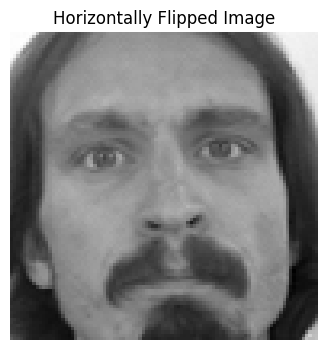

In [21]:
# View the horizontally flipped image
plt.figure(figsize=(4, 4))
plt.imshow(facialpoints_df_copy['Image'][0], cmap='gray')
plt.title('Horizontally Flipped Image', fontsize=12)
plt.axis('off')
plt.show()


In [22]:
# Since we flipped images horizontally, the x-coordinates must be mirrored
# y-coordinates stay the same; x-coordinates become (96 - original_x)
for i in range(len(columns)):
    if i % 2 == 0:  # Even indices are x-coordinates
        facialpoints_df_copy[columns[i]] = facialpoints_df_copy[columns[i]].apply(
            lambda x: 96.0 - float(x)
        )

print("X-coordinates adjusted for horizontal flip!")


X-coordinates adjusted for horizontal flip!


/tmp/ipykernel_2863/1097813287.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[0].plot(facialpoints_df.loc[0][j-1], facialpoints_df.loc[0][j], 'ro', markersize=4)
/tmp/ipykernel_2863/1097813287.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[1].plot(facialpoints_df_copy.loc[0][j-1], facialpoints_df_copy.loc[0][j], 'ro', markersize=4)


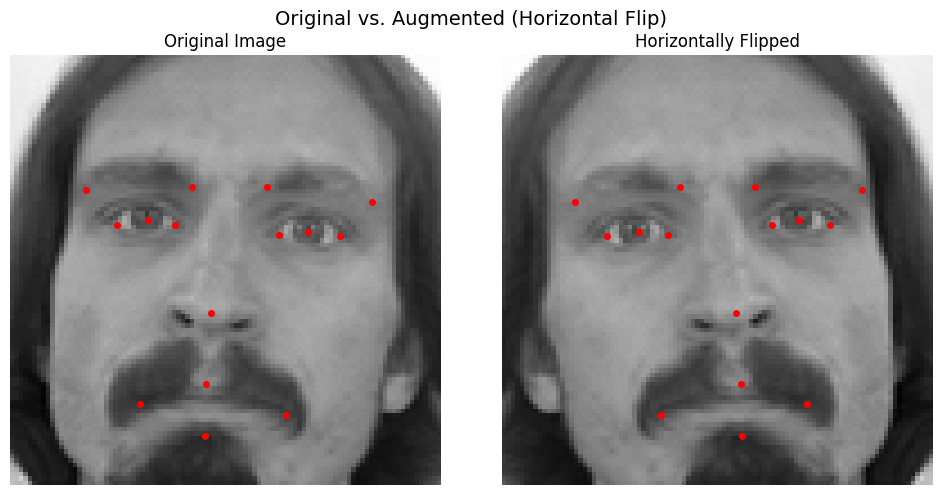

In [23]:
# Compare original and flipped images side by side with keypoints

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original
axes[0].imshow(facialpoints_df['Image'][0], cmap='gray')
for j in range(1, 31, 2):
    axes[0].plot(facialpoints_df.loc[0][j-1], facialpoints_df.loc[0][j], 'ro', markersize=4)
axes[0].set_title('Original Image', fontsize=12)
axes[0].axis('off')

# Flipped
axes[1].imshow(facialpoints_df_copy['Image'][0], cmap='gray')
for j in range(1, 31, 2):
    axes[1].plot(facialpoints_df_copy.loc[0][j-1], facialpoints_df_copy.loc[0][j], 'ro', markersize=4)
axes[1].set_title('Horizontally Flipped', fontsize=12)
axes[1].axis('off')

plt.suptitle('Original vs. Augmented (Horizontal Flip)', fontsize=14)
plt.tight_layout()
plt.show()


In [24]:
# Concatenate the original dataframe with the augmented (flipped) dataframe
facialpoints_df_augmented = np.concatenate((facialpoints_df, facialpoints_df_copy))

print(f"Original size: {len(facialpoints_df)}")
print(f"After horizontal flip augmentation: {facialpoints_df_augmented.shape[0]}")


Original size: 406
After horizontal flip augmentation: 812


In [25]:
# Verify the augmented dataset size
print(f"Augmented dataset shape: {facialpoints_df_augmented.shape}")


Augmented dataset shape: (812, 31)


In [26]:
# Augment images by randomly increasing brightness
# Multiply pixel values by a random factor between 1.0 and 2.0
# Clip values to stay in the valid range [0, 255]

facialpoints_df_copy = copy.copy(facialpoints_df)
facialpoints_df_copy['Image'] = facialpoints_df['Image'].apply(
    lambda x: np.clip(random.uniform(1.0, 2.0) * x, 0.0, 255.0)
)

# Add brightness-augmented images to the dataset
facialpoints_df_augmented = np.concatenate((facialpoints_df_augmented, facialpoints_df_copy))

print(f"After brightness augmentation: {facialpoints_df_augmented.shape[0]}")


After brightness augmentation: 1218


/tmp/ipykernel_2863/752965274.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[0].plot(facialpoints_df.loc[0][j-1], facialpoints_df.loc[0][j], 'ro', markersize=4)
/tmp/ipykernel_2863/752965274.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[1].plot(facialpoints_df_copy.loc[0][j-1], facialpoints_df_copy.loc[0][j], 'ro', markersize=4)


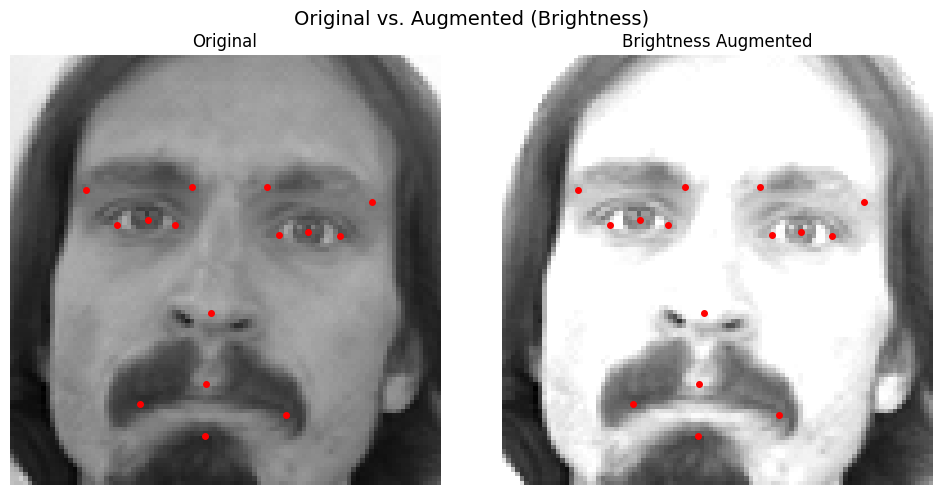

In [27]:
# Compare original and brightness-augmented images

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(facialpoints_df['Image'][0], cmap='gray')
for j in range(1, 31, 2):
    axes[0].plot(facialpoints_df.loc[0][j-1], facialpoints_df.loc[0][j], 'ro', markersize=4)
axes[0].set_title('Original', fontsize=12)
axes[0].axis('off')

axes[1].imshow(facialpoints_df_copy['Image'][0], cmap='gray')
for j in range(1, 31, 2):
    axes[1].plot(facialpoints_df_copy.loc[0][j-1], facialpoints_df_copy.loc[0][j], 'ro', markersize=4)
axes[1].set_title('Brightness Augmented', fontsize=12)
axes[1].axis('off')

plt.suptitle('Original vs. Augmented (Brightness)', fontsize=14)
plt.tight_layout()
plt.show()


<a id="mini-challenge-3"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #D97706, #B45309); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">🏆 Mini Challenge #3</span>

- Augment images by flipping them vertically
(Hint: Flip along x-axis and note that if we are flipping along x-axis, x co-ordinates won't change)


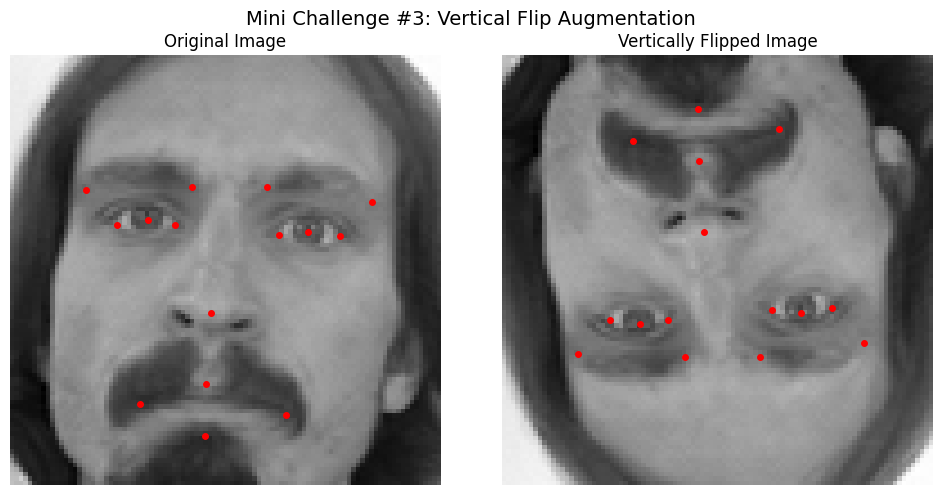

In [28]:
# ====================================================================
# Mini Challenge #3: Augment images by flipping vertically (along x-axis)
# Note:
#   - x-coordinates remain unchanged during a vertical flip
#   - y-coordinates become: (image_height - y) = (96.0 - y)
# ====================================================================

facialpoints_df_vertical = copy.copy(facialpoints_df)

# 1. Flip image arrays vertically (along axis=0)
facialpoints_df_vertical['Image'] = facialpoints_df_vertical['Image'].apply(
    lambda img: np.flip(img, axis=0)
)

# 2. Adjust y-coordinates (all odd column indices in first 30 columns)
keypoint_cols = [col for col in facialpoints_df.columns if col != 'Image']
for i, col in enumerate(keypoint_cols):
    if i % 2 == 1:  # Odd index = y-coordinate
        facialpoints_df_vertical[col] = facialpoints_df_vertical[col].apply(
            lambda y_val: 96.0 - float(y_val)
        )

# 3. Compare original vs. vertically flipped image side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original image (sample 0)
axes[0].imshow(facialpoints_df['Image'].iloc[0], cmap='gray')
for j in range(1, 31, 2):
    axes[0].plot(facialpoints_df.iloc[0, j - 1], facialpoints_df.iloc[0, j], 'ro', markersize=4)
axes[0].set_title('Original Image', fontsize=12)
axes[0].axis('off')

# Vertically flipped image (sample 0)
axes[1].imshow(facialpoints_df_vertical['Image'].iloc[0], cmap='gray')
for j in range(1, 31, 2):
    axes[1].plot(facialpoints_df_vertical.iloc[0, j - 1], facialpoints_df_vertical.iloc[0, j], 'ro', markersize=4)
axes[1].set_title('Vertically Flipped Image', fontsize=12)
axes[1].axis('off')

plt.suptitle('Mini Challenge #3: Vertical Flip Augmentation', fontsize=14)
plt.tight_layout()
plt.show()

<a id="5-normalization"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">05. Perform Normalization and Training Data Preparation</span>


In [29]:
# Normalize pixel values from [0, 255] to [0, 1]
# The Image column is at index 30 (31st column, 0-indexed)
img = facialpoints_df_augmented[:, 30]
img = img / 255.0

# Create array of shape (num_samples, 96, 96, 1) for the CNN input
X = np.empty((len(img), 96, 96, 1))

for i in range(len(img)):
    X[i,] = np.expand_dims(img[i], axis=2)

X = np.asarray(X).astype(np.float32)

print(f"Input features shape (X): {X.shape}")
print(f"Pixel value range after normalization: [{X.min():.3f}, {X.max():.3f}]")


Input features shape (X): (1218, 96, 96, 1)
Pixel value range after normalization: [0.000, 1.000]


In [30]:
# Extract the target keypoint coordinates (first 30 columns)
y = facialpoints_df_augmented[:, :30]
y = np.asarray(y).astype(np.float32)

print(f"Target labels shape (y): {y.shape}")
print(f"Coordinate value range: [{y.min():.1f}, {y.max():.1f}]")


Target labels shape (y): (1218, 30)
Coordinate value range: [5.3, 95.4]


In [31]:
# Split data into training (90%) and testing (10%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

print(f"Training set: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set:  X_test={X_test.shape}, y_test={y_test.shape}")


Training set: X_train=(1096, 96, 96, 1), y_train=(1096, 30)
Testing set:  X_test=(122, 96, 96, 1), y_test=(122, 30)


/tmp/ipykernel_2863/2042724427.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


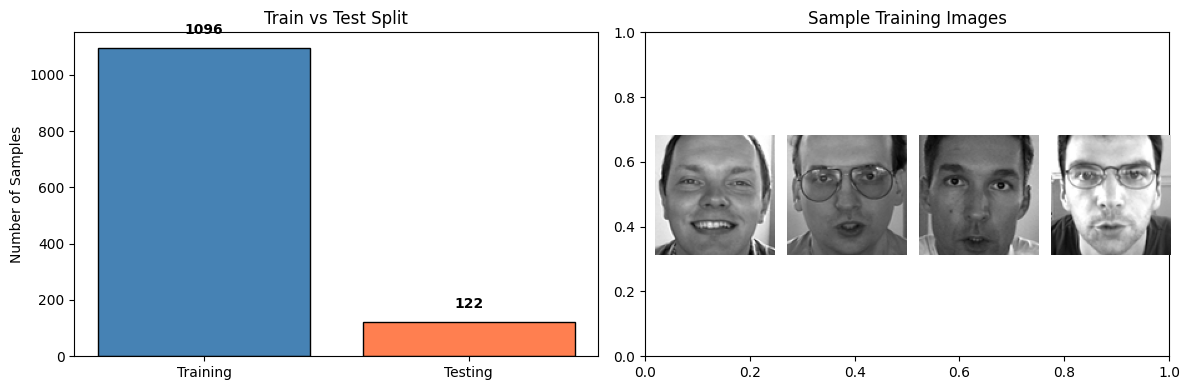

In [32]:
# Visualize the train/test split

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Split sizes
labels = ['Training', 'Testing']
sizes = [len(X_train), len(X_test)]
colors = ['steelblue', 'coral']
axes[0].bar(labels, sizes, color=colors, edgecolor='black')
axes[0].set_title('Train vs Test Split', fontsize=12)
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate(sizes):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Sample images from training set
axes[1].set_title('Sample Training Images', fontsize=12)
for i in range(4):
    ax_sub = fig.add_axes([0.55 + i * 0.11, 0.2, 0.1, 0.6])
    ax_sub.imshow(X_train[i].squeeze(), cmap='gray')
    ax_sub.axis('off')

plt.tight_layout()
plt.show()


<a id="mini-challenge-4"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #D97706, #B45309); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">🏆 Mini Challenge #4</span>

- Try a different value for 'test_size' and check the size of the training and testing datasets
- Randomly visualize 64 images from the original and augmented data. Does the data makes sense?


Train/Test Split Comparison:
  Original Split (test_size=0.10): X_train=(1096, 96, 96, 1), X_test=(122, 96, 96, 1)
  New Split      (test_size=0.20): X_train_exp=(974, 96, 96, 1), X_test_exp=(244, 96, 96, 1)


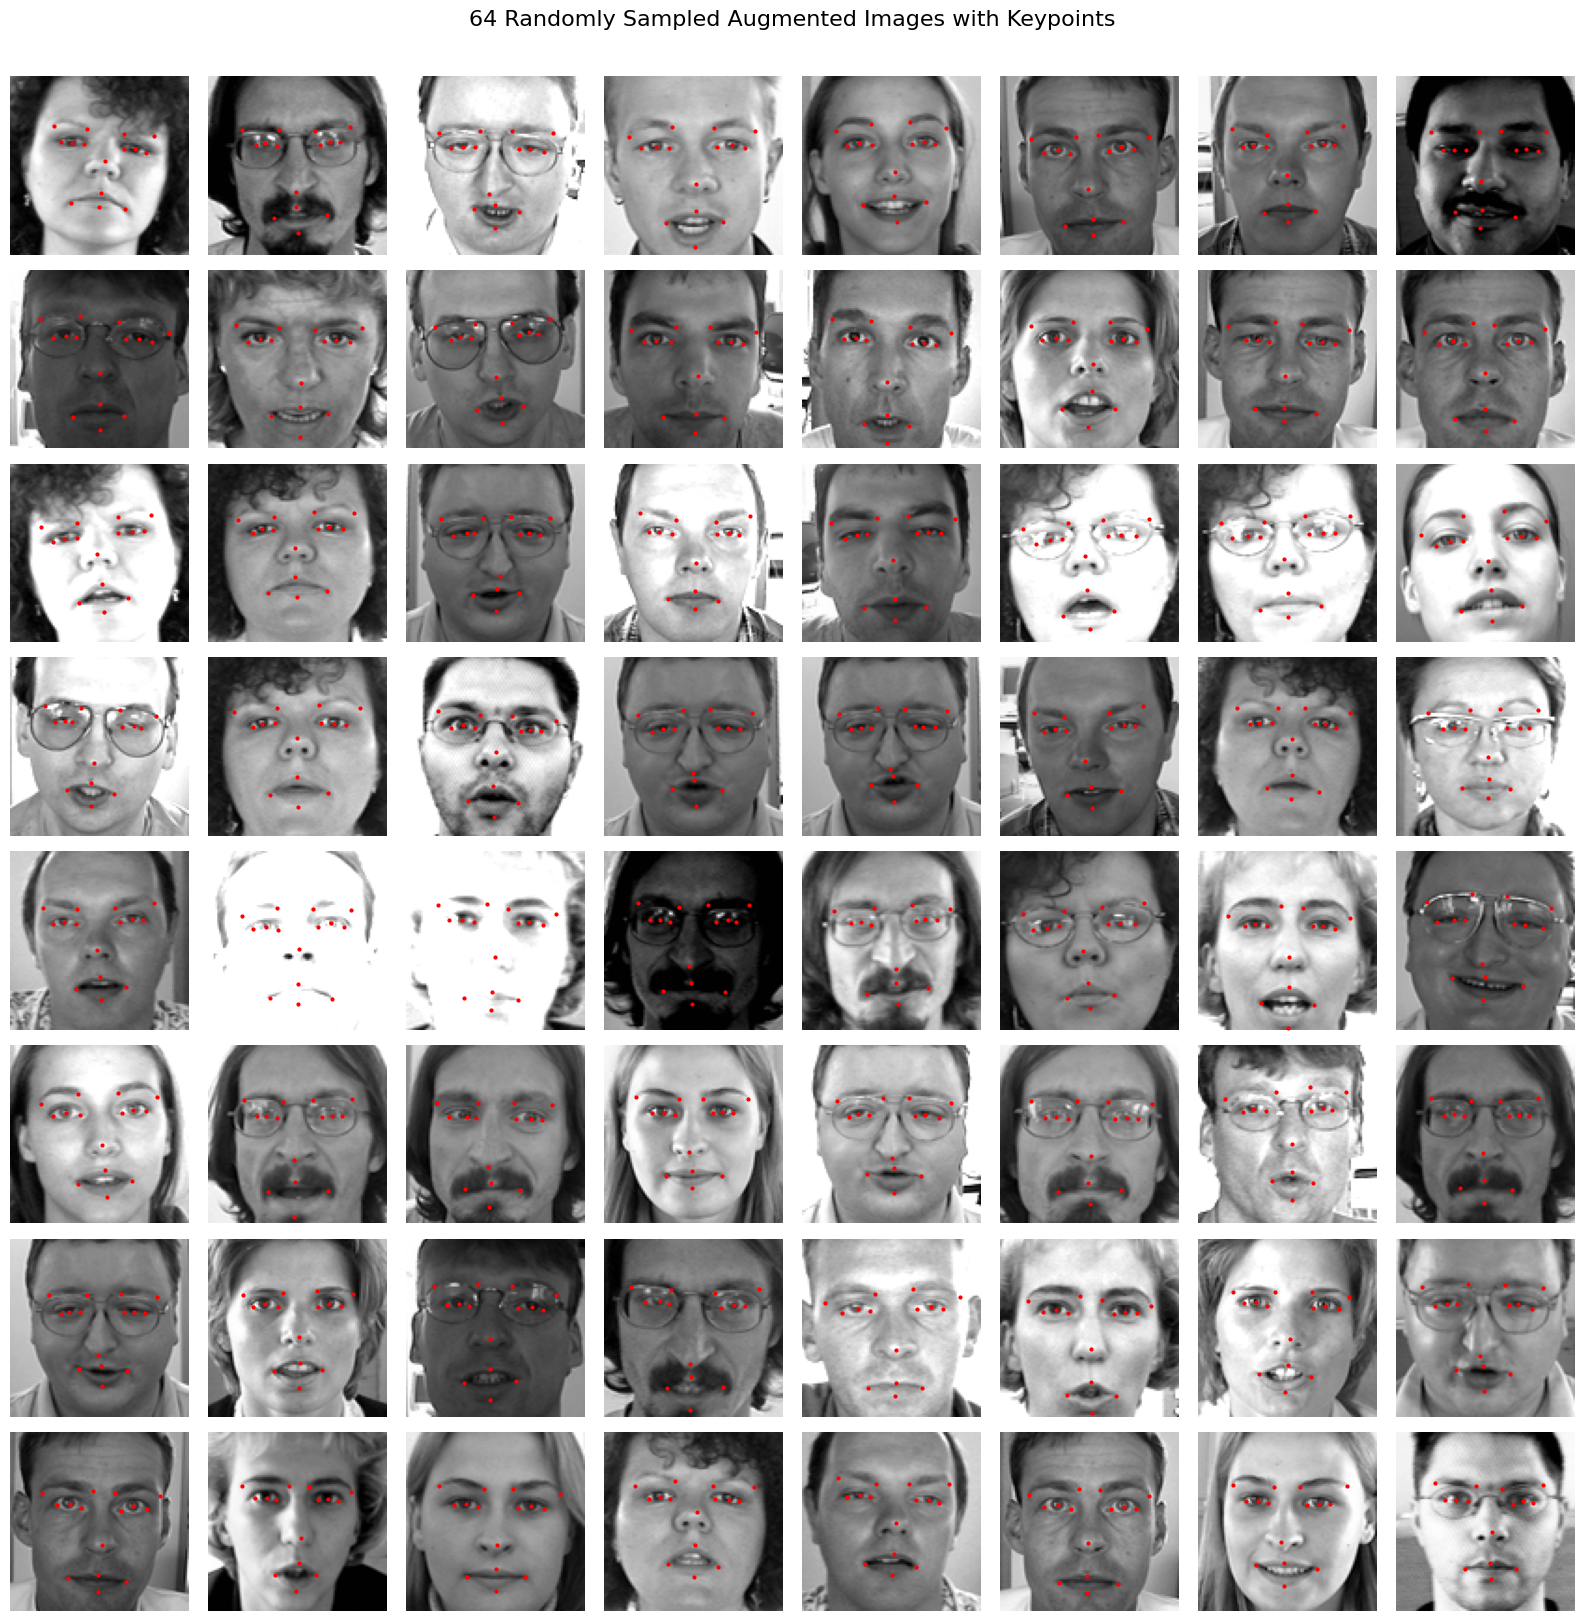

In [33]:
# ====================================================================
# Mini Challenge #4:
# 1. Experiment with a different test_size (e.g., 0.20 instead of 0.10)
# 2. Randomly visualize 64 images from the augmented dataset with keypoints
# ====================================================================

# Part 1: Try test_size = 0.20 (20% testing, 80% training)
X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Train/Test Split Comparison:")
print(f"  Original Split (test_size=0.10): X_train={X_train.shape}, X_test={X_test.shape}")
print(f"  New Split      (test_size=0.20): X_train_exp={X_train_exp.shape}, X_test_exp={X_test_exp.shape}")

# Part 2: Randomly sample and visualize 64 images from augmented data
fig = plt.figure(figsize=(16, 16))
fig.suptitle('64 Randomly Sampled Augmented Images with Keypoints', fontsize=16, y=1.01)

random_sample_indices = np.random.choice(len(X), size=64, replace=False)

for idx, img_i in enumerate(random_sample_indices):
    ax = fig.add_subplot(8, 8, idx + 1)
    plt.imshow(X[img_i].squeeze(), cmap='gray')
    for j in range(1, 31, 2):
        plt.plot(y[img_i][j - 1], y[img_i][j], 'ro', markersize=2)
    plt.axis('off')

plt.tight_layout()
plt.show()

<a id="6-deep-learning-theory"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">06. Understand the Theory and Intuition Behind Deep Neural Networks</span>


<a id="61-dl-history"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.1 Deep Learning History</span>

There are many trained off the shelf convolutional neural networks that are readily available such as:

- **LeNet-5** (1998): 7 level convolutional neural network developed by LeCun that works in classifying hand writing numbers.
- **AlexNet** (2012): Offered massive improvement, error reduction from 26% to 15.3%.
- **ZFNet** (2013): Achieved error of 14.8%.
- **GoogLeNet/Inception** (2014): Error reduction to 6.67% which is at par with human level accuracy.
- **VGGNet** (2014): Demonstrated that depth of the network is a critical component for good performance.
- **ResNet** (2015): Residual Neural Network includes "skip connection" feature and therefore enabled training of 152 layers without vanishing gradient issues. Error of 3.57% which is superior to humans.

> Source: https://medium.com/analytics-vidhya/cnns-architectures-lenet-alexnet-vgg-googlenet-resnet-and-more-666091488df5


<a id="62-cnn"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.2 Convolutional Neural Networks</span>

- CNN in action: https://www.cs.ryerson.ca/~aharley/vis/conv/flat.html

A CNN pipeline consists of the following stages:
1. **Convolutional Layer**: Kernels/Feature Detectors slide across the image to extract features.
2. **Activation (ReLU)**: Non-linear activation function applied after convolution.
3. **Pooling Layer (Downsampling)**: Reduces the spatial dimensions using pooling filters.
4. **Flattening**: Converts the 2D feature maps into a 1D vector.
5. **Fully Connected Layers**: Maps the flattened features to the output key facial points coordinates (X₁, Y₁, X₂, Y₂, X₃, Y₃, ...).

> Photo Credit: https://commons.wikimedia.org/wiki/File:Artificial_neural_network.svg


![CNN Architecture Pipeline](assets/task6_convolutional_neural_networks.png)


<a id="63-resnet"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.3 ResNet (Residual Network)</span>

- As CNNs grow deeper, vanishing gradient tend to occur which negatively impact network performance.
- Vanishing gradient problem occurs when the gradient is back-propagated to earlier layers which results in a very small gradient.
- Residual Neural Network includes "skip connection" feature which enables training of 152 layers without vanishing gradient issues.
- ResNet works by adding "identity mappings" on top of the CNN.
- ImageNet contains 11 million images and 11,000 categories.
- ImageNet is used to train ResNet deep network.

The skip connection adds the input **x** directly to the output of a block of layers **F(x)**, producing **F(x) + x**. This ensures that gradients can flow directly through the identity shortcut, preventing them from vanishing.


![Residual Block Diagram](assets/task6_residual_neural_networks.png)


<a id="7-build-model"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">07. Build Deep Residual Neural Network Model</span>


<a id="71-model-architecture"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">7.1 Model Architecture</span>

The model uses a **RES-BLOCK** structure consisting of:
- **Convolution Block** → **Identity Block** → **Identity Block** → Output

### Final Model Pipeline:
1. **Input** (96×96×1 grayscale image)
2. **Zero Padding**
3. **Conv2D** → **BatchNorm, ReLU** → **MaxPool2D**
4. **RES-BLOCK** (Stage 1)
5. **RES-BLOCK** (Stage 2)
6. **AveragePooling2D** → **Flatten()**
7. **Dense Layer, ReLU, Dropout**
8. **Dense Layer, ReLU, Dropout**
9. **Dense Layer, ReLU** → **Key-Points Output (30 values)**


![ResNet Architecture and Final Model Pipeline](assets/task7_resnet_architecture.png)


<a id="72-conv-identity-blocks"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">7.2 Convolution Block vs. Identity Block</span>

### Convolution Block (Main Path):
`Input → Conv2D → MaxPool2D → BatchNorm, ReLU → Conv2D(3×3) → BatchNorm, ReLU → Conv2D → BatchNorm`

**Short Path:** `Conv2D → MaxPool2D → BatchNorm`

Both paths are **added together** → **ReLU** → Output

---

### Identity Block (Main Path):
`Input → Conv2D → BatchNorm, ReLU → Conv2D(3×3) → BatchNorm, ReLU → Conv2D → BatchNorm`

**Short Path:** The original input is passed directly (identity shortcut — no convolution or pooling)

Both paths are **added together** → **ReLU** → Output


![Convolution Block and Identity Block](assets/task7_residual_blocks.png)


In [34]:
def res_block(X, filter, stage):
    """
    Residual Block consisting of:
    1. Convolution Block (with projection shortcut)
    2. Identity Block 1
    3. Identity Block 2
    """

    X_copy = X
    f1, f2, f3 = filter

    # ===== CONVOLUTION BLOCK =====

    # Main Path
    X = Conv2D(f1, (1, 1), strides=(1, 1),
               name=f'res_{stage}_conv_a',
               kernel_initializer=GlorotUniform(seed=0))(X)
    X = MaxPooling2D((2, 2))(X)
    X = BatchNormalization(axis=3, name=f'bn_{stage}_conv_a')(X)
    X = Activation('relu')(X)

    X = Conv2D(f2, (3, 3), strides=(1, 1), padding='same',
               name=f'res_{stage}_conv_b',
               kernel_initializer=GlorotUniform(seed=0))(X)
    X = BatchNormalization(axis=3, name=f'bn_{stage}_conv_b')(X)
    X = Activation('relu')(X)

    X = Conv2D(f3, (1, 1), strides=(1, 1),
               name=f'res_{stage}_conv_c',
               kernel_initializer=GlorotUniform(seed=0))(X)
    X = BatchNormalization(axis=3, name=f'bn_{stage}_conv_c')(X)

    # Short Path (Projection)
    X_copy = Conv2D(f3, (1, 1), strides=(1, 1),
                    name=f'res_{stage}_conv_copy',
                    kernel_initializer=GlorotUniform(seed=0))(X_copy)
    X_copy = MaxPooling2D((2, 2))(X_copy)
    X_copy = BatchNormalization(axis=3, name=f'bn_{stage}_conv_copy')(X_copy)

    # Add main and short paths
    X = Add()([X, X_copy])
    X = Activation('relu')(X)

    # ===== IDENTITY BLOCK 1 =====

    X_copy = X

    X = Conv2D(f1, (1, 1), strides=(1, 1),
               name=f'res_{stage}_identity_1_a',
               kernel_initializer=GlorotUniform(seed=0))(X)
    X = BatchNormalization(axis=3, name=f'bn_{stage}_identity_1_a')(X)
    X = Activation('relu')(X)

    X = Conv2D(f2, (3, 3), strides=(1, 1), padding='same',
               name=f'res_{stage}_identity_1_b',
               kernel_initializer=GlorotUniform(seed=0))(X)
    X = BatchNormalization(axis=3, name=f'bn_{stage}_identity_1_b')(X)
    X = Activation('relu')(X)

    X = Conv2D(f3, (1, 1), strides=(1, 1),
               name=f'res_{stage}_identity_1_c',
               kernel_initializer=GlorotUniform(seed=0))(X)
    X = BatchNormalization(axis=3, name=f'bn_{stage}_identity_1_c')(X)

    X = Add()([X, X_copy])
    X = Activation('relu')(X)

    # ===== IDENTITY BLOCK 2 =====

    X_copy = X

    X = Conv2D(f1, (1, 1), strides=(1, 1),
               name=f'res_{stage}_identity_2_a',
               kernel_initializer=GlorotUniform(seed=0))(X)
    X = BatchNormalization(axis=3, name=f'bn_{stage}_identity_2_a')(X)
    X = Activation('relu')(X)

    X = Conv2D(f2, (3, 3), strides=(1, 1), padding='same',
               name=f'res_{stage}_identity_2_b',
               kernel_initializer=GlorotUniform(seed=0))(X)
    X = BatchNormalization(axis=3, name=f'bn_{stage}_identity_2_b')(X)
    X = Activation('relu')(X)

    X = Conv2D(f3, (1, 1), strides=(1, 1),
               name=f'res_{stage}_identity_2_c',
               kernel_initializer=GlorotUniform(seed=0))(X)
    X = BatchNormalization(axis=3, name=f'bn_{stage}_identity_2_c')(X)

    X = Add()([X, X_copy])
    X = Activation('relu')(X)

    return X


In [35]:
# ============================================
# Build the Deep Residual Neural Network
# ============================================

# Verify that res_block is loaded
if 'res_block' not in globals():
    raise NameError("res_block is not defined. Please execute the preceding cell (defining res_block) before running this cell.")

input_shape = (96, 96, 1)
X_input = Input(input_shape)

# Zero-padding
X = ZeroPadding2D((3, 3))(X_input)

# Stage 1: Initial convolution
X = Conv2D(64, (7, 7), strides=(2, 2), name='conv1',
           kernel_initializer=GlorotUniform(seed=0))(X)
X = BatchNormalization(axis=3, name='bn_conv1')(X)
X = Activation('relu')(X)
X = MaxPooling2D((3, 3), strides=(2, 2))(X)

# Stage 2: Residual Block with filters [64, 64, 256]
X = res_block(X, filter=[64, 64, 256], stage=2)

# Stage 3: Residual Block with filters [128, 128, 512]
X = res_block(X, filter=[128, 128, 512], stage=3)

# Average Pooling
X = AveragePooling2D((2, 2), name='avg_pool')(X)

# Fully connected head
X = Flatten()(X)
X = Dense(4096, activation='relu')(X)
X = Dropout(0.2)(X)
X = Dense(2048, activation='relu')(X)
X = Dropout(0.1)(X)
X = Dense(30, activation='relu')(X)  # 30 outputs = 15 keypoints × 2 coordinates

# Create model
model = Model(inputs=X_input, outputs=X, name='ResNet_KeyPointDetector')
model.summary()

Model: "ResNet_KeyPointDetector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 102, 102,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 48, 48,    │      3,200 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv1            │ (None, 48, 48,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48, 48,    │          0 │ bn_conv1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 23, 23,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_a        │ (None, 23, 23,    │      4,160 │ max_pooling2d[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 11, 11,    │          0 │ res_2_conv_a[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_a         │ (None, 11, 11,    │        256 │ max_pooling2d_1[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 11, 11,    │          0 │ bn_2_conv_a[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_b        │ (None, 11, 11,    │     36,928 │ activation_1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_b         │ (None, 11, 11,    │        256 │ res_2_conv_b[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 11, 11,    │          0 │ bn_2_conv_b[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_copy     │ (None, 23, 23,    │     16,640 │ max_pooling2d[0]… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_c        │ (None, 11, 11,    │     16,640 │ activation_2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 11, 11,    │          0 │ res_2_conv_copy[… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_c         │ (None, 11, 11,    │      1,024 │ res_2_conv_c[0][

 Total params: 18,016,286 (68.73 MB)

 Trainable params: 18,007,710 (68.69 MB)

 Non-trainable params: 8,576 (33.50 KB)

<a id="mini-challenge-5"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #D97706, #B45309); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">🏆 Mini Challenge #5</span>

- Experiment with changing the network architecture by removing 2 MaxPooling layers from the Res Block. What did you notice when you print out the network summary?
- Try to add 'X = res_block(X, filter= [256,256,1024], stage= 4)' Block after stage #3 block and make sure the change is reflected on the network summary


In [36]:
# ====================================================================
# Mini Challenge #5 Solution:
# 1. Build ResNet architecture with Stage 4 added
# 2. ResNet block without MaxPooling layers (parameter count comparison)
# ====================================================================

# --------------------------------------------------------------------
# Part 1: Build Model with Stage 4 Added: [256, 256, 1024]
# --------------------------------------------------------------------
input_shape = (96, 96, 1)
X_input = Input(input_shape)

# Initial Convolution & MaxPool
X = ZeroPadding2D((3, 3))(X_input)
X = Conv2D(64, (7, 7), strides=(2, 2), name='mc5_conv1',
           kernel_initializer=GlorotUniform(seed=0))(X)
X = BatchNormalization(axis=3, name='mc5_bn_conv1')(X)
X = Activation('relu')(X)
X = MaxPooling2D((3, 3), strides=(2, 2))(X)

# Stages 2, 3, and Stage 4
X = res_block(X, filter=[64, 64, 256], stage=2)
X = res_block(X, filter=[128, 128, 512], stage=3)
X = res_block(X, filter=[256, 256, 1024], stage=4)  # <-- Added Stage 4

# Fully connected head
X = AveragePooling2D((2, 2), name='mc5_avg_pool')(X)
X = Flatten()(X)
X = Dense(4096, activation='relu')(X)
X = Dropout(0.2)(X)
X = Dense(2048, activation='relu')(X)
X = Dropout(0.1)(X)
X = Dense(30, activation='relu')(X)

model_stage4 = Model(inputs=X_input, outputs=X, name='ResNet_With_Stage4')
print("===== ResNet Architecture with Stage 4 Added =====")
model_stage4.summary()

===== ResNet Architecture with Stage 4 Added =====


Model: "ResNet_With_Stage4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 102, 102,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mc5_conv1 (Conv2D)  │ (None, 48, 48,    │      3,200 │ zero_padding2d_1… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mc5_bn_conv1        │ (None, 48, 48,    │        256 │ mc5_conv1[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 48, 48,    │          0 │ mc5_bn_conv1[0][… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 23, 23,    │          0 │ activation_19[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_a        │ (None, 23, 23,    │      4,160 │ max_pooling2d_5[… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 11, 11,    │          0 │ res_2_conv_a[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_a         │ (None, 11, 11,    │        256 │ max_pooling2d_6[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 11, 11,    │          0 │ bn_2_conv_a[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_b        │ (None, 11, 11,    │     36,928 │ activation_20[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_b         │ (None, 11, 11,    │        256 │ res_2_conv_b[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 11, 11,    │          0 │ bn_2_conv_b[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_copy     │ (None, 23, 23,    │     16,640 │ max_pooling2d_5[… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_c        │ (None, 11, 11,    │     16,640 │ activation_21[0]… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 11, 11,    │          0 │ res_2_conv_copy[… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_c         │ (None, 11, 11,    │      1,024 │ res_2_conv_c[0][

 Total params: 17,585,694 (67.08 MB)

 Trainable params: 17,565,854 (67.01 MB)

 Non-trainable params: 19,840 (77.50 KB)

<a id="8-train-model"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">08. Compile and Train Deep Learning Model</span>


In [37]:
# Compile the model with Adam optimizer
# Note: 'lr' parameter is deprecated — use 'learning_rate' instead
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    loss='mean_squared_error',
    optimizer=optimizer,
    metrics=['accuracy']
)

print("Model compiled successfully!")


Model compiled successfully!


In [38]:
# Save the best model during training (lowest validation loss)
# In Keras 3 (TensorFlow 2.16+), checkpoint filenames must end with '.keras'
import os

checkpoint_path = 'weights.keras' if os.path.exists('/content') else 'data/weights.keras'
os.makedirs(os.path.dirname(checkpoint_path) or '.', exist_ok=True)

checkpointer = ModelCheckpoint(
    filepath=checkpoint_path,
    verbose=1,
    save_best_only=True
)

print(f"Checkpoint callback ready! Saving best model to: {checkpoint_path}")

Checkpoint callback ready! Saving best model to: weights.keras


In [39]:
# Train the model
history = model.fit(
    X_train, y_train,
    batch_size=256,
    epochs=100,
    validation_split=0.05,
    callbacks=[checkpointer]
)


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2974 - loss: 1568.0971   
Epoch 1: val_loss improved from None to 2515.22437, saving model to weights.keras

Epoch 1: finished saving model to weights.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 50s 5s/step - accuracy: 0.3391 - loss: 1105.3058 - val_accuracy: 0.0000e+00 - val_loss: 2515.2244
Epoch 2/100
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.2515 - loss: 289.0045
Epoch 2: val_loss improved from 2515.22437 to 2425.65747, saving model to weights.keras

Epoch 2: finished saving model to weights.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 513ms/step - accuracy: 0.4524 - loss: 251.6518 - val_accuracy: 0.8182 - val_loss: 2425.6575
Epoch 3/100
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8277 - loss: 218.1614
Epoch 3: val_loss improved from 2425.65747 to 2335.96899, saving model to weights.keras

Epoch 3: finished saving model to weights.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 448ms/step - accuracy: 0.8329 - loss: 202.3783 - val_accuracy:

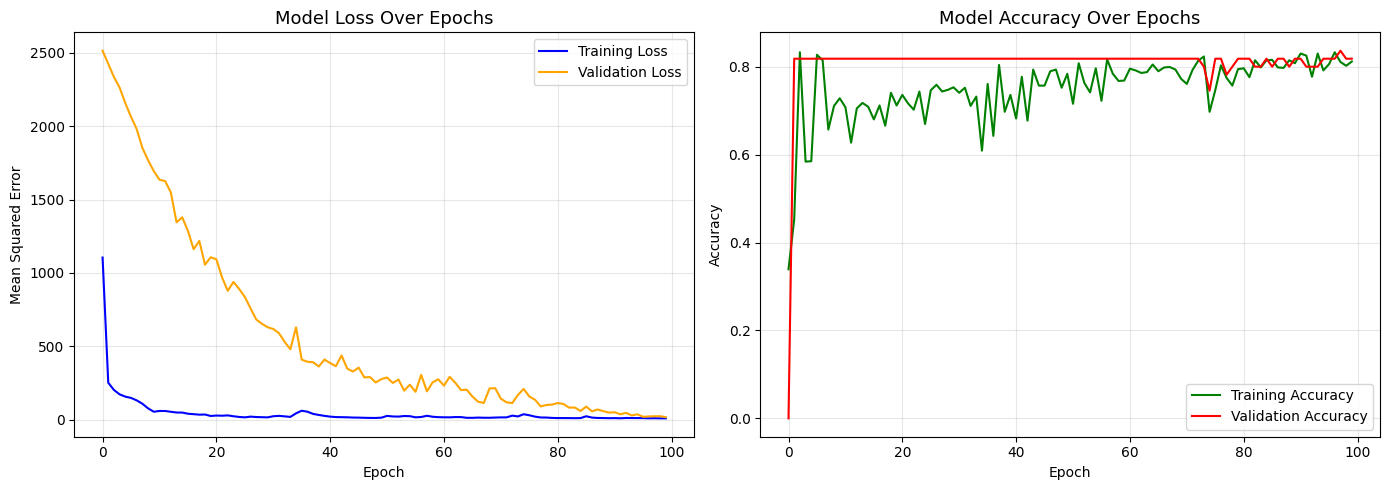

In [40]:
# Plot training and validation loss curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history.history['loss'], label='Training Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_title('Model Loss Over Epochs', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Mean Squared Error')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(history.history['accuracy'], label='Training Accuracy', color='green')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
axes[1].set_title('Model Accuracy Over Epochs', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [41]:
# Save the trained model in the standard .keras format
import os

save_path = 'KeyPointDetector.keras' if os.path.exists('/content') else 'data/KeyPointDetector.keras'
os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
model.save(save_path)
print(f"Trained model saved successfully to: {save_path}")

# (Optional) Export architecture to JSON for reference if supported
try:
    model_json = model.to_json()
    json_path = 'KeyPointDetector.json' if os.path.exists('/content') else 'data/KeyPointDetector.json'
    with open(json_path, 'w') as json_file:
        json_file.write(model_json)
    print(f"Model architecture JSON saved to: {json_path}")
except Exception as e:
    print(f"Note on JSON export (Keras 3 recommends .keras format): {e}")

Trained model saved successfully to: KeyPointDetector.keras
Model architecture JSON saved to: KeyPointDetector.json


<a id="9-assess-performance"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">09. Assess Trained Model Performance</span>


In [42]:
# ====================================================================
# Load the Model for Evaluation
# Supports modern .keras format as well as pre-existing weights/JSON
# ====================================================================
import os

keras_candidates = [
    'weights.keras', 'data/weights.keras', '/content/weights.keras',
    'KeyPointDetector.keras', 'data/KeyPointDetector.keras', '/content/KeyPointDetector.keras'
]
saved_keras_path = next((p for p in keras_candidates if os.path.exists(p)), None)

if saved_keras_path:
    model = load_model(saved_keras_path)
    print(f"Model loaded successfully from: {saved_keras_path}")
else:
    # Fallback to pre-existing JSON architecture and weights if available
    json_candidates = ['data/KeyPointDetector.json', 'KeyPointDetector.json', '/content/KeyPointDetector.json']
    weights_candidates = ['data/weights.hdf5', 'weights.hdf5', '/content/weights.hdf5']

    json_path = next((p for p in json_candidates if os.path.exists(p)), None)
    weights_path = next((p for p in weights_candidates if os.path.exists(p)), None)

    if json_path and weights_path:
        with open(json_path, 'r') as json_file:
            json_SavedModel = json_file.read()
        try:
            model = tf.keras.models.model_from_json(json_SavedModel)
            model.load_weights(weights_path)
            optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
            model.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['accuracy'])
            print(f"Pre-trained model loaded from {json_path} and {weights_path}!")
        except Exception as e:
            print(f"Note on loading pre-existing weights: {e}")
    else:
        print("Using the model currently in memory.")

Model loaded successfully from: weights.keras


In [43]:
# Evaluate the model on the test set
result = model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Loss (MSE): {result[0]:.4f}")
print(f"Test Accuracy:   {result[1]:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 534ms/step - accuracy: 0.8361 - loss: 38.7514

Test Loss (MSE): 38.7514
Test Accuracy:   0.8361


In [44]:
# Make predictions on the test set
df_predict = model.predict(X_test)

print(f"Predictions shape: {df_predict.shape}")
print(f"Predicted coordinate range: [{df_predict.min():.1f}, {df_predict.max():.1f}]")


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 551ms/step
Predictions shape: (122, 30)
Predicted coordinate range: [14.2, 95.8]


In [45]:
# Calculate the Root Mean Squared Error (RMSE)
rms = sqrt(mean_squared_error(y_test, df_predict))

print(f"RMSE: {rms:.4f}")
print(f"Average pixel error per coordinate: {rms:.2f} pixels")


RMSE: 6.2251
Average pixel error per coordinate: 6.23 pixels


In [46]:
# Convert predictions into a readable dataframe
df_predict = pd.DataFrame(df_predict, columns=columns)
print(f"Predictions dataframe shape: {df_predict.shape}")
df_predict.head()


Predictions dataframe shape: (122, 30)


,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_x,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y
0,32.018375,38.909359,67.751678,37.811081,37.975544,39.145100,26.083109,40.721153,61.849201,38.967255,...,50.543316,59.008896,36.900211,77.879280,64.291496,76.305946,50.528500,72.787941,51.459560,85.804565
1,66.320930,36.589798,30.384264,35.842682,60.287945,37.193008,71.639336,38.239925,36.769268,36.786396,...,47.492474,56.952507,61.887482,73.292130,33.963959,71.693672,47.306728,68.996201,47.475956,80.977173
2,32.777843,37.041431,62.089558,35.532505,37.777393,37.824394,28.169197,39.107494,57.414944,37.478394,...,48.217041,56.288200,36.960434,76.798988,59.213852,75.550011,47.976574,71.715065,48.689861,84.516098
3,63.738514,38.064445,33.284122,38.746063,58.231419,39.425743,68.010765,39.854130,38.707500,40.052956,...,48.527271,56.933998,60.638435,79.658821,36.754662,79.856392,48.197784,73.349144,48.303349,87.543304
4,30.499191,38.706230,69.041542,38.085484,37.596012,38.892757,23.935215,40.287952,63.120312,39.231022,...,50.463406,55.895782,35.433060,78.740784,65.232414,77.955956,50.459587,72.108696,51.180847,86.609604


/tmp/ipykernel_2863/1266091127.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(df_predict.loc[i][j-1], df_predict.loc[i][j], 'go', markersize=3)


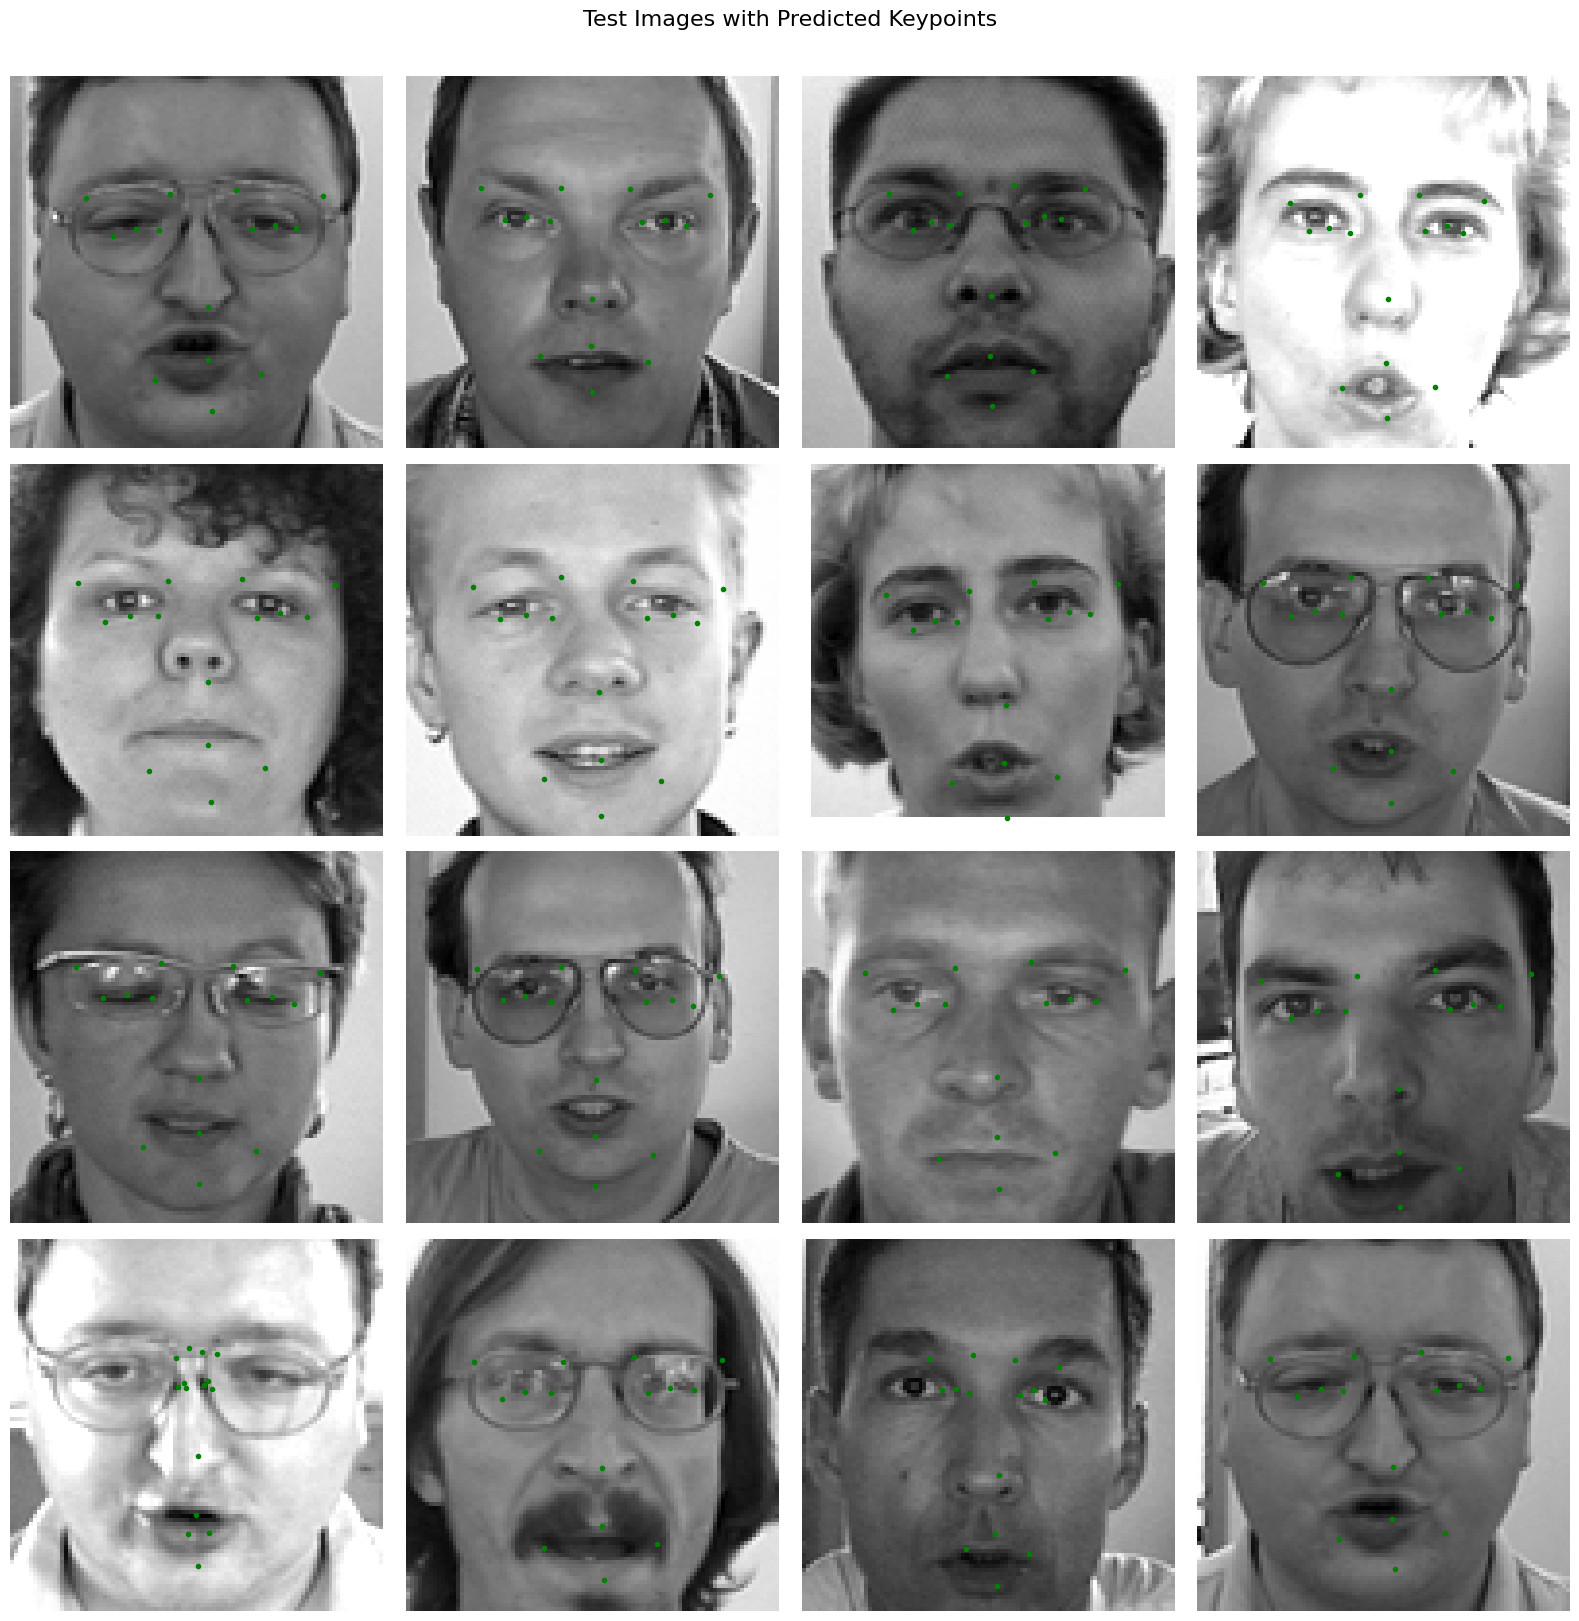

In [47]:
# Plot test images with their predicted keypoints

fig = plt.figure(figsize=(16, 16))
fig.suptitle('Test Images with Predicted Keypoints', fontsize=16, y=1.01)

for i in range(16):
    ax = fig.add_subplot(4, 4, i + 1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    for j in range(1, 31, 2):
        plt.plot(df_predict.loc[i][j-1], df_predict.loc[i][j], 'go', markersize=3)
    plt.axis('off')

plt.tight_layout()
plt.show()


/tmp/ipykernel_2863/3446538406.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(df_predict.loc[i][j-1], df_predict.loc[i][j], 'g^', markersize=4, label='Predicted' if j == 1 else '')


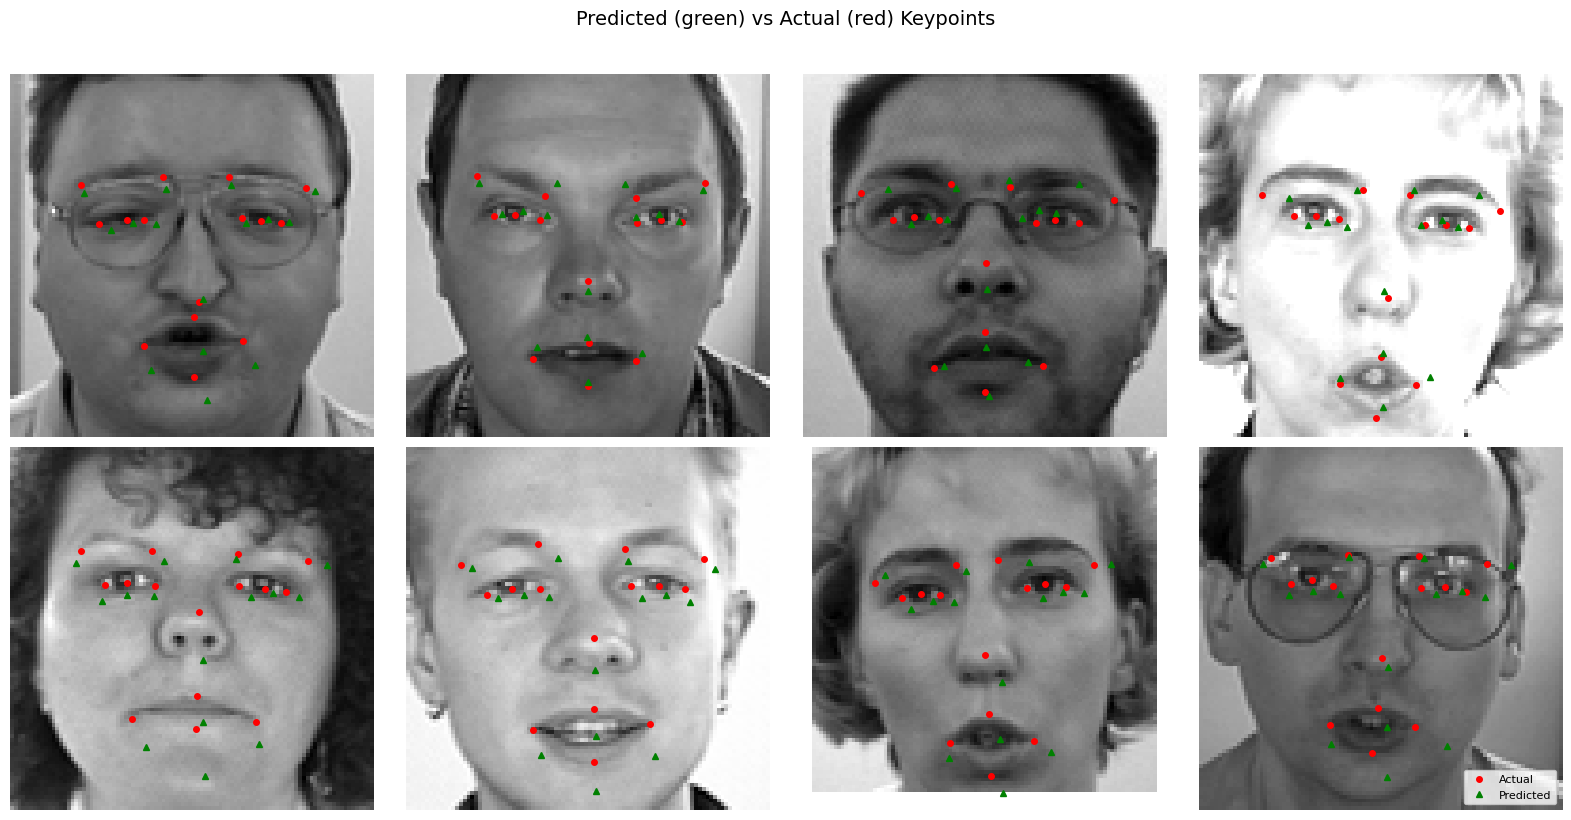

In [48]:
# Compare predicted vs. actual keypoints on sample test images

fig = plt.figure(figsize=(16, 8))
fig.suptitle('Predicted (green) vs Actual (red) Keypoints', fontsize=14, y=1.02)

for i in range(8):
    ax = fig.add_subplot(2, 4, i + 1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')

    # Actual keypoints (red)
    for j in range(1, 31, 2):
        plt.plot(y_test[i][j-1], y_test[i][j], 'ro', markersize=4, label='Actual' if j == 1 else '')

    # Predicted keypoints (green)
    for j in range(1, 31, 2):
        plt.plot(df_predict.loc[i][j-1], df_predict.loc[i][j], 'g^', markersize=4, label='Predicted' if j == 1 else '')

    plt.axis('off')

# Add legend to the last subplot
plt.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()


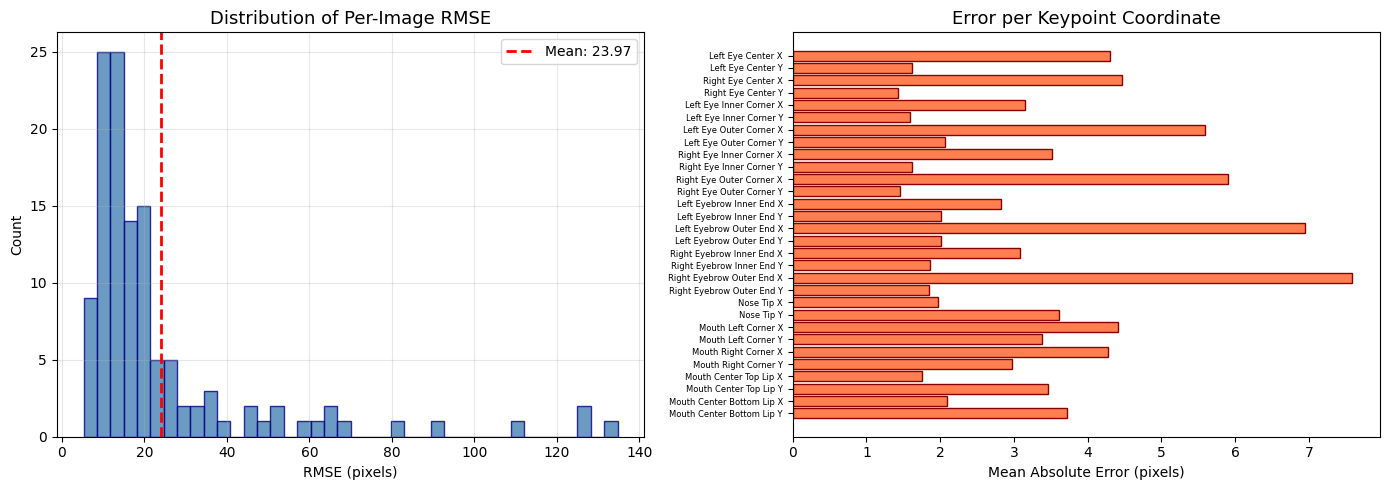

In [49]:
# Visualize the prediction error distribution

errors = np.sqrt(np.sum((y_test - df_predict.values) ** 2, axis=1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of per-image RMSE
axes[0].hist(errors, bins=40, color='steelblue', edgecolor='navy', alpha=0.8)
axes[0].axvline(errors.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {errors.mean():.2f}')
axes[0].set_title('Distribution of Per-Image RMSE', fontsize=13)
axes[0].set_xlabel('RMSE (pixels)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Per-coordinate error
coord_errors = np.abs(y_test - df_predict.values).mean(axis=0)
coord_names = [col.replace('_', ' ').title() for col in columns[:30]]
axes[1].barh(range(len(coord_errors)), coord_errors, color='coral', edgecolor='darkred')
axes[1].set_yticks(range(len(coord_errors)))
axes[1].set_yticklabels(coord_names, fontsize=6)
axes[1].set_xlabel('Mean Absolute Error (pixels)')
axes[1].set_title('Error per Keypoint Coordinate', fontsize=13)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

<a id="congratulations"></a>

<div style="
  background: linear-gradient(145deg, #064e3b, #065f46);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 24px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #fbbf24, #f59e0b, #d97706);
    -webkit-mask:
      linear-gradient(#fff 0 0) content-box,
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  🎉 <b>Congratulations on Finishing the Project!</b>
</div>


<a id="mini-challenge-solutions"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #D97706, #B45309);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">📋 Mini Challenge Solutions</span>


<a id="solution-1"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #D97706, #B45309); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">🏆 Mini Challenge #1 — Solution</span>


In [50]:
# ====================================================================
# Mini Challenge #1: Obtain average, minimum, and maximum values
# for 'right_eye_center_x'
# ====================================================================

col_name = 'right_eye_center_x'

avg_val = facialpoints_df[col_name].mean()
min_val = facialpoints_df[col_name].min()
max_val = facialpoints_df[col_name].max()

print("Statistics for 'right_eye_center_x':")
print(f"  Average (Mean) : {avg_val:.2f} pixels")
print(f"  Minimum        : {min_val:.2f} pixels")
print(f"  Maximum        : {max_val:.2f} pixels")

# Display full summary statistics for 'right_eye_center_x'
facialpoints_df[[col_name]].describe()

Statistics for 'right_eye_center_x':
  Average (Mean) : 29.79 pixels
  Minimum        : 24.47 pixels
  Maximum        : 34.21 pixels


,right_eye_center_x
count,406.000000
mean,29.790536
std,1.712079
min,24.467092
25%,28.693370
50%,29.919768
75%,30.975163
max,34.209750


<a id="solution-2"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #D97706, #B45309); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">🏆 Mini Challenge #2 — Solution</span>


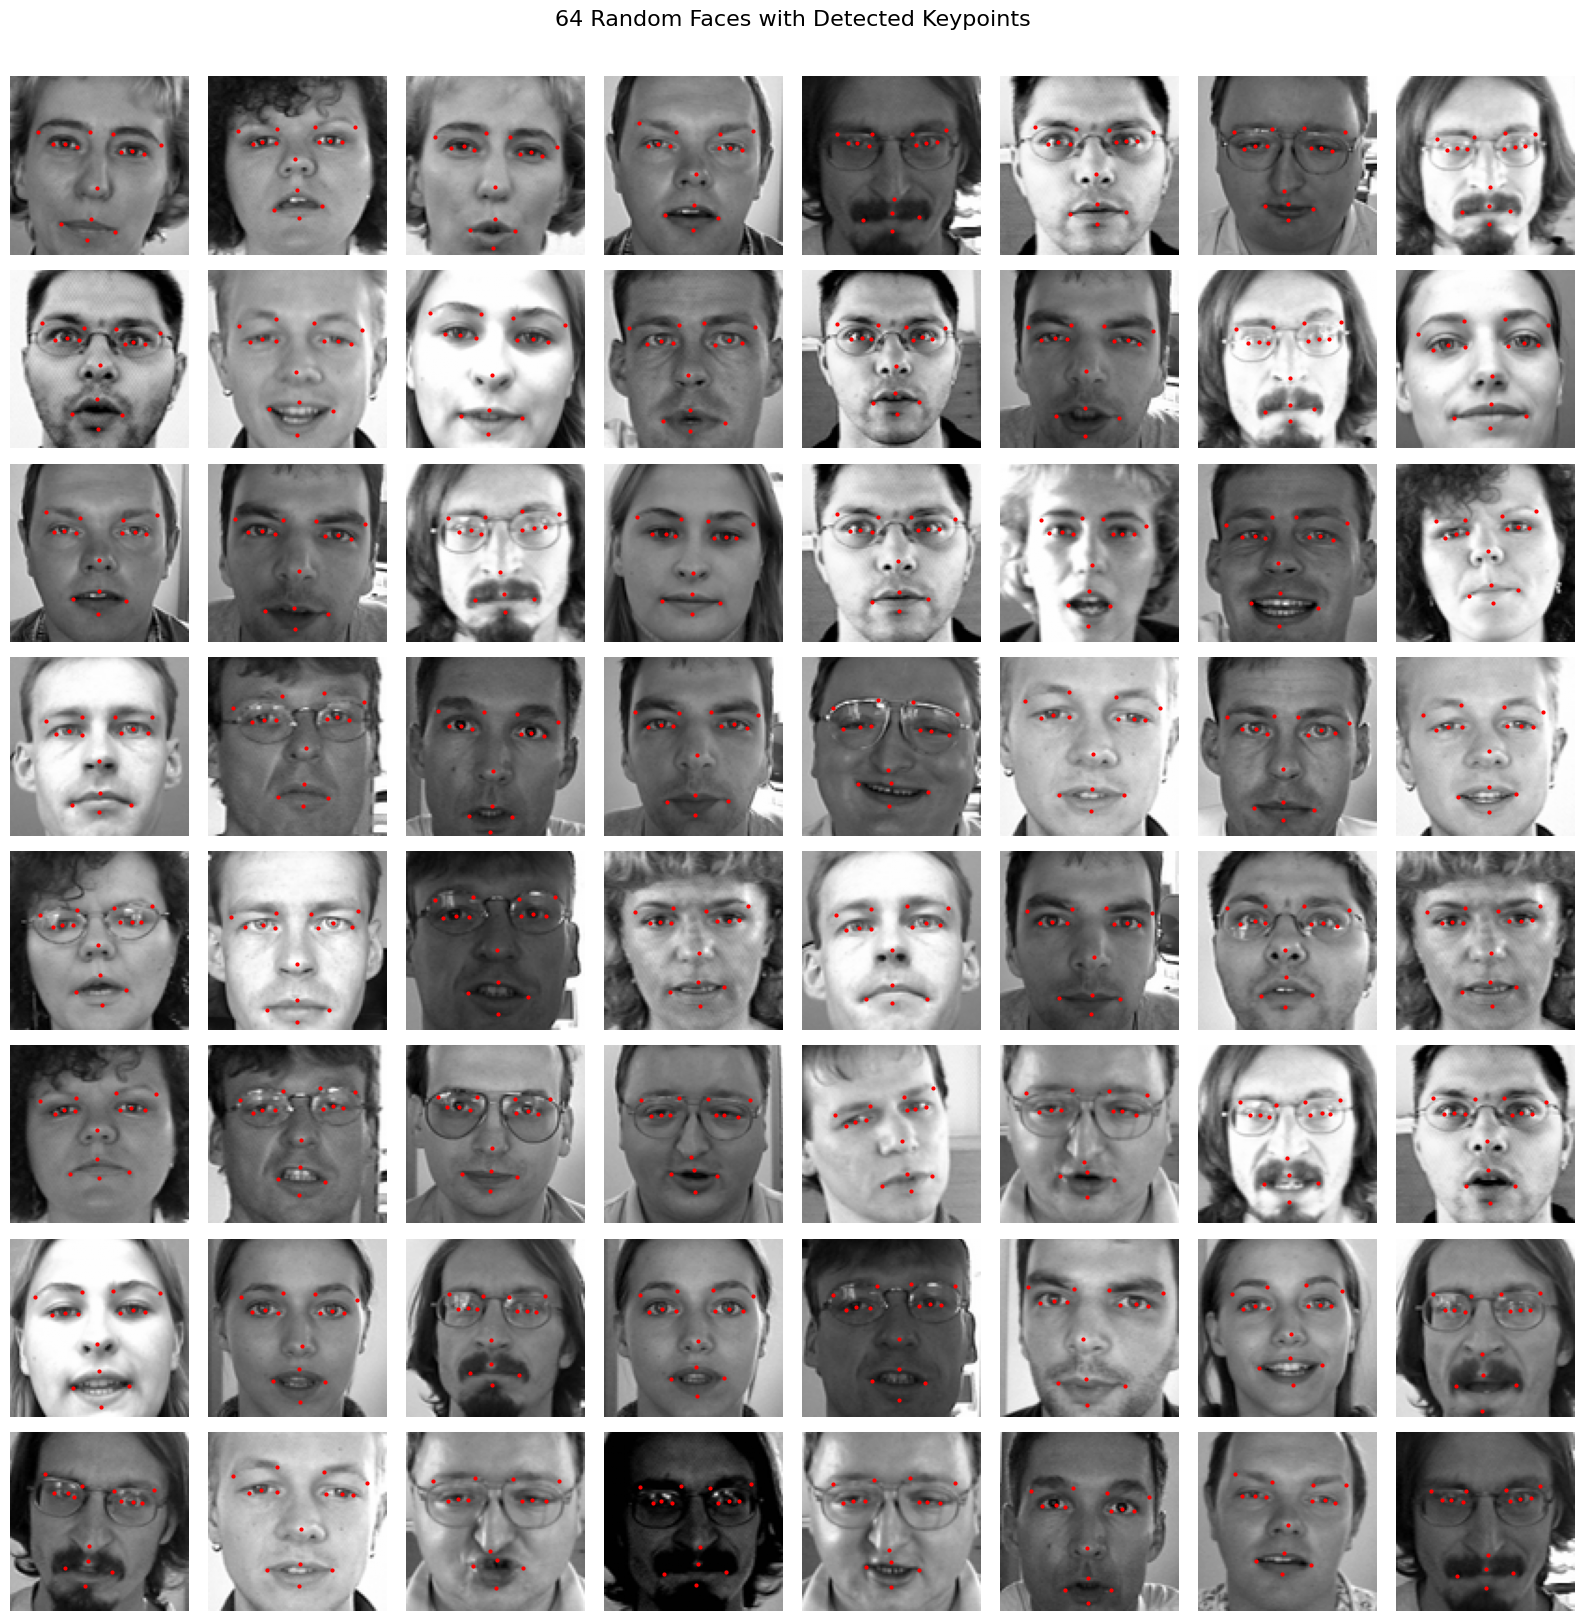

In [51]:
# ====================================================================
# Mini Challenge #2: Plot 64 random images from the dataset with keypoints
# ====================================================================

fig = plt.figure(figsize=(16, 16))
fig.suptitle('64 Random Faces with Detected Keypoints', fontsize=16, y=1.01)

for i in range(64):
    img_idx = np.random.randint(0, len(facialpoints_df))
    ax = fig.add_subplot(8, 8, i + 1)
    plt.imshow(facialpoints_df['Image'].iloc[img_idx], cmap='gray')
    for j in range(1, 31, 2):
        plt.plot(
            facialpoints_df.iloc[img_idx, j - 1],
            facialpoints_df.iloc[img_idx, j],
            'ro',
            markersize=2
        )
    plt.axis('off')

plt.tight_layout()
plt.show()

<a id="solution-3"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #D97706, #B45309); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">🏆 Mini Challenge #3 — Solution</span>


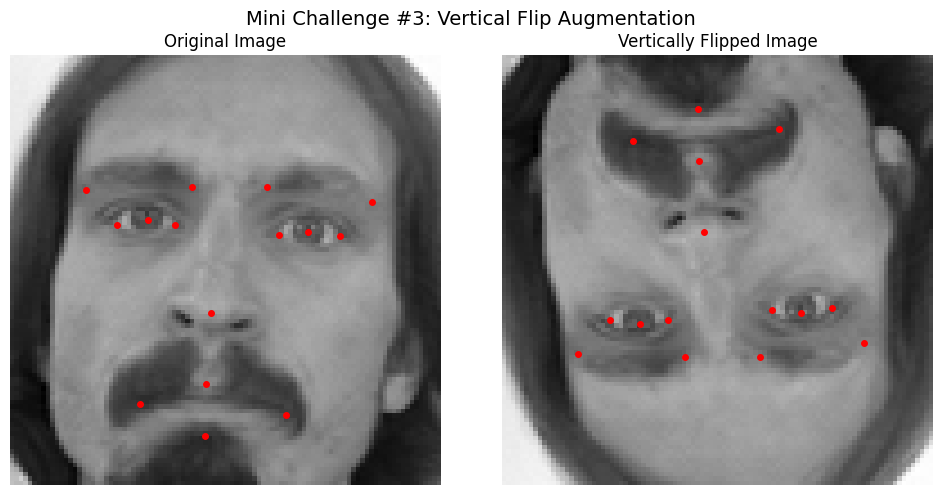

In [52]:
# ====================================================================
# Mini Challenge #3: Augment images by flipping vertically (along x-axis)
# Note:
#   - x-coordinates remain unchanged during a vertical flip
#   - y-coordinates become: (image_height - y) = (96.0 - y)
# ====================================================================

facialpoints_df_vertical = copy.copy(facialpoints_df)

# 1. Flip image arrays vertically (along axis=0)
facialpoints_df_vertical['Image'] = facialpoints_df_vertical['Image'].apply(
    lambda img: np.flip(img, axis=0)
)

# 2. Adjust y-coordinates (all odd column indices in first 30 columns)
keypoint_cols = [col for col in facialpoints_df.columns if col != 'Image']
for i, col in enumerate(keypoint_cols):
    if i % 2 == 1:  # Odd index = y-coordinate
        facialpoints_df_vertical[col] = facialpoints_df_vertical[col].apply(
            lambda y_val: 96.0 - float(y_val)
        )

# 3. Compare original vs. vertically flipped image side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original image (sample 0)
axes[0].imshow(facialpoints_df['Image'].iloc[0], cmap='gray')
for j in range(1, 31, 2):
    axes[0].plot(facialpoints_df.iloc[0, j - 1], facialpoints_df.iloc[0, j], 'ro', markersize=4)
axes[0].set_title('Original Image', fontsize=12)
axes[0].axis('off')

# Vertically flipped image (sample 0)
axes[1].imshow(facialpoints_df_vertical['Image'].iloc[0], cmap='gray')
for j in range(1, 31, 2):
    axes[1].plot(facialpoints_df_vertical.iloc[0, j - 1], facialpoints_df_vertical.iloc[0, j], 'ro', markersize=4)
axes[1].set_title('Vertically Flipped Image', fontsize=12)
axes[1].axis('off')

plt.suptitle('Mini Challenge #3: Vertical Flip Augmentation', fontsize=14)
plt.tight_layout()
plt.show()

<a id="solution-5"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #D97706, #B45309); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">🏆 Mini Challenge #4 — Solution</span>


<div style="background-color: #012549ff; border-left: 4px solid #d97706; padding: 14px 18px; border-radius: 6px; margin: 10px 0;">

#### 📌 Key Takeaways for Mini Challenge #4:

1. **Removing 2 MaxPooling Layers from `res_block`:**
   - In the Convolution Block of `res_block`, there are two `MaxPooling2D((2, 2))` operations (one in the main path and one in the shortcut path).
   - Removing them prevents downsampling the spatial feature dimensions.
   - When the tensor reaches `Flatten()`, the feature map volume is substantially larger, causing a **massive increase in trainable parameters** in the first dense layer (`Dense(4096)`).

2. **Adding Stage 4 (`X = res_block(X, filter=[256, 256, 1024], stage=4)`):**
   - Adding a 4th residual stage after Stage 3 introduces deeper representation learning with 1024 filter channels.
   - The code below builds the model with Stage 4 added and displays the full architecture summary.

</div>

In [54]:
# ====================================================================
# Mini Challenge #5 Solution:
# 1. Build ResNet architecture with Stage 4 added
# 2. ResNet block without MaxPooling layers (parameter count comparison)
# ====================================================================

# --------------------------------------------------------------------
# Part 1: Build Model with Stage 4 Added: [256, 256, 1024]
# --------------------------------------------------------------------
input_shape = (96, 96, 1)
X_input = Input(input_shape)

# Initial Convolution & MaxPool
X = ZeroPadding2D((3, 3))(X_input)
X = Conv2D(64, (7, 7), strides=(2, 2), name='mc5_conv1',
           kernel_initializer=GlorotUniform(seed=0))(X)
X = BatchNormalization(axis=3, name='mc5_bn_conv1')(X)
X = Activation('relu')(X)
X = MaxPooling2D((3, 3), strides=(2, 2))(X)

# Stages 2, 3, and Stage 4
X = res_block(X, filter=[64, 64, 256], stage=2)
X = res_block(X, filter=[128, 128, 512], stage=3)
X = res_block(X, filter=[256, 256, 1024], stage=4)  # <-- Added Stage 4

# Fully connected head
X = AveragePooling2D((2, 2), name='mc5_avg_pool')(X)
X = Flatten()(X)
X = Dense(4096, activation='relu')(X)
X = Dropout(0.2)(X)
X = Dense(2048, activation='relu')(X)
X = Dropout(0.1)(X)
X = Dense(30, activation='relu')(X)

model_stage4 = Model(inputs=X_input, outputs=X, name='ResNet_With_Stage4')
print("===== ResNet Architecture with Stage 4 Added =====")
model_stage4.summary()

===== ResNet Architecture with Stage 4 Added =====


Model: "ResNet_With_Stage4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 102, 102,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mc5_conv1 (Conv2D)  │ (None, 48, 48,    │      3,200 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mc5_bn_conv1        │ (None, 48, 48,    │        256 │ mc5_conv1[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_47       │ (None, 48, 48,    │          0 │ mc5_bn_conv1[0][… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 23, 23,    │          0 │ activation_47[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_a        │ (None, 23, 23,    │      4,160 │ max_pooling2d_12… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 11, 11,    │          0 │ res_2_conv_a[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_a         │ (None, 11, 11,    │        256 │ max_pooling2d_13… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_48       │ (None, 11, 11,    │          0 │ bn_2_conv_a[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_b        │ (None, 11, 11,    │     36,928 │ activation_48[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_b         │ (None, 11, 11,    │        256 │ res_2_conv_b[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_49       │ (None, 11, 11,    │          0 │ bn_2_conv_b[0][0] │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_copy     │ (None, 23, 23,    │     16,640 │ max_pooling2d_12… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_2_conv_c        │ (None, 11, 11,    │     16,640 │ activation_49[0]… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 11, 11,    │          0 │ res_2_conv_copy[… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2_conv_c         │ (None, 11, 11,    │      1,024 │ res_2_conv_c[0][

 Total params: 17,585,694 (67.08 MB)

 Trainable params: 17,565,854 (67.01 MB)

 Non-trainable params: 19,840 (77.50 KB)